{'source_behavior': 'walk', 'target_behavior': 'spin', 'source_path': '/Users/adi/Desktop/EmergentRobotSelf/Checkpoints_States_selectedGraphs/WalkSpinJump_relu/WSJ_relu_2_2026-01-30_23-24-40/models/c022_b01_walk_plateau_2026-02-04_11-56-55_for_play.pth', 'target_path': '/Users/adi/Desktop/EmergentRobotSelf/Checkpoints_States_selectedGraphs/WalkSpinJump_relu/WSJ_relu_2_2026-01-30_23-24-40/models/c022_b02_spin_plateau_2026-02-04_14-11-09_for_play.pth', 'self_mean_persistence_all_layers': 0.8382808812080867, 'task_mean_persistence_all_layers': 0.5840227222833477, 'self_change_percent_all_layers': 16.171911879191324, 'task_change_percent_all_layers': 41.59772777166523, 'task_over_self_change_ratio': 2.572220778990871, 'self_n_scored_all_layers': 126, 'task_n_scored_all_layers': 122}


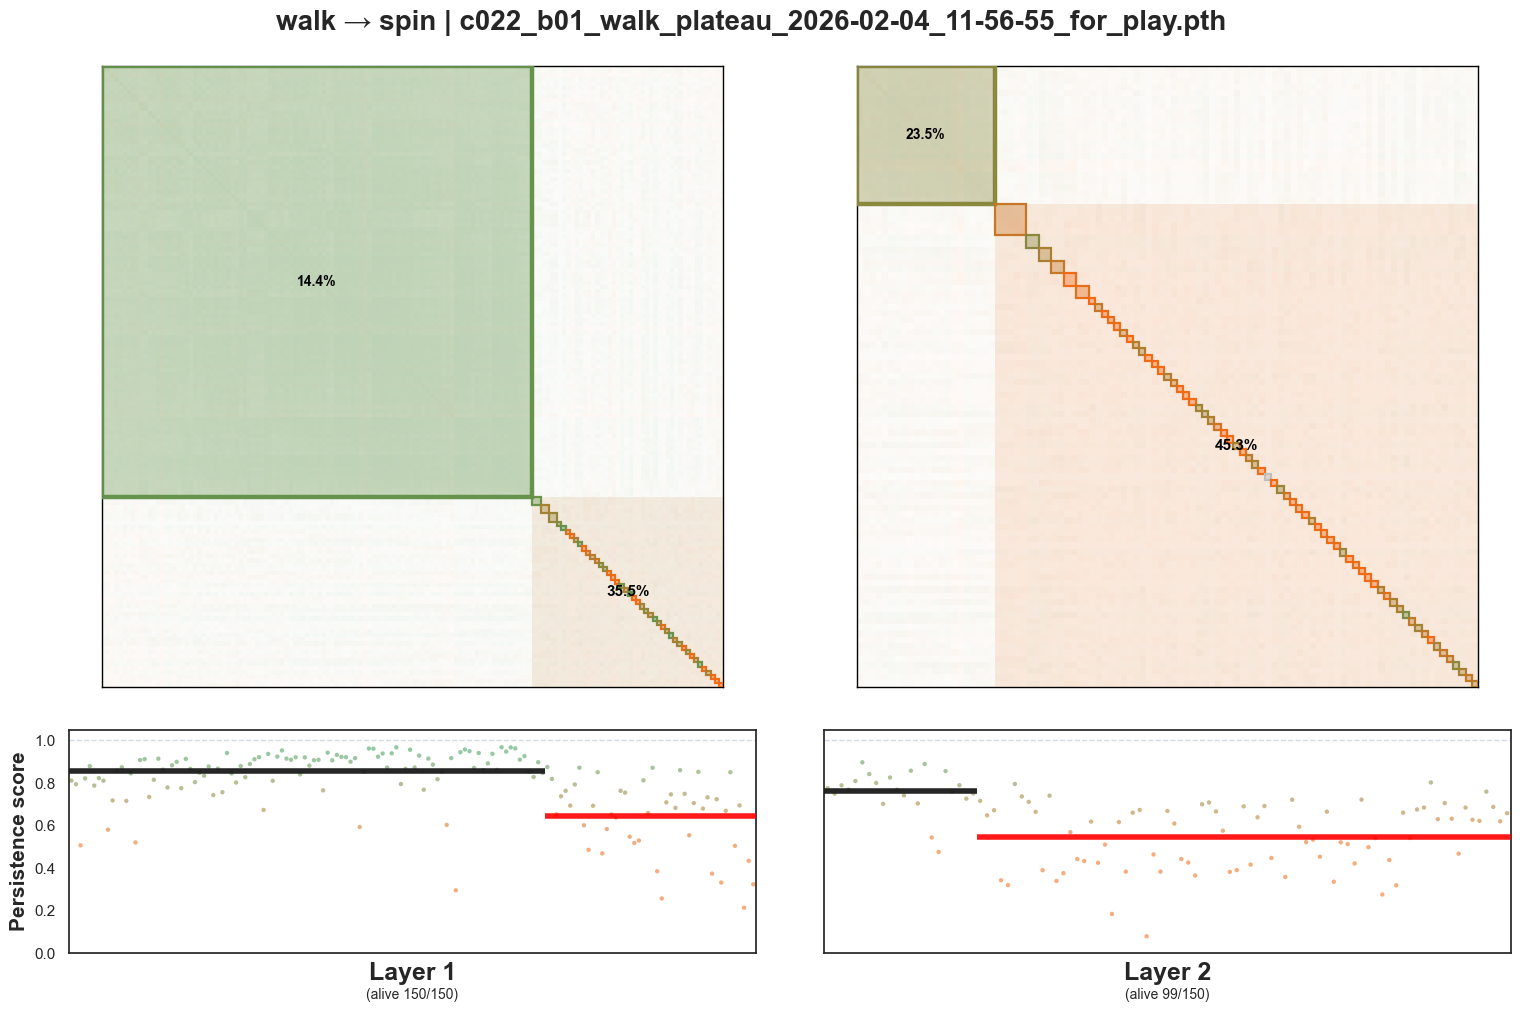

In [5]:
# ============================================================
# === SELF-CONTAINED ONE-SIDED TRANSITION ANALYSIS (2 MODELS)
# === Source-defined modules (self = largest source block)
# === Target compared only on one side (source -> target)
# === Includes summary + 2 plots:
# ===   (1) source heatmap with self/task overlays colored by change
# ===   (2) per-neuron persistence strip (ordered by source blocks)
# ============================================================

from __future__ import annotations

import os
import re
import random
from pathlib import Path

%matplotlib inline
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.optimize import linear_sum_assignment
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import reverse_cuthill_mckee, connected_components
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
# ============================================================
# ========================= CONFIG ===========================
# ============================================================

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "AnalysisScripts":
    REPO_ROOT = REPO_ROOT.parent

# --- Pick ONE transition pair ---
SOURCE_MODEL_PATH = f"{REPO_ROOT}/Checkpoints_States_selectedGraphs/WalkSpinJump_relu/WSJ_relu_2_2026-01-30_23-24-40/models/c022_b01_walk_plateau_2026-02-04_11-56-55_for_play.pth"
TARGET_MODEL_PATH = f"{REPO_ROOT}/Checkpoints_States_selectedGraphs/WalkSpinJump_relu/WSJ_relu_2_2026-01-30_23-24-40/models/c022_b02_spin_plateau_2026-02-04_14-11-09_for_play.pth"

# --- States pool ---
ALL_STATES_PATH = f"{REPO_ROOT}/Checkpoints_States_selectedGraphs/StatesConcat/ALL_states_concat.npy"
N_ALL_STATES = 400_000

# --- Layers ---
LAYER_INDICES = [0, 1]

# --- Numerics ---
SEED = 42
EPS = 1e-8
MIN_STD = 1e-5
ACTIVATION = "relu"   # {"elu","relu","tanh"}

# --- Source block-diagonalisation ---
TAU = 0.70
BD_MIN_BLOCK_SIZE = 1

# --- Heatmap visuals ---
CMAP = "RdBu_r"
VMIN, VCENTER, VMAX = -1.0, 0.0, 1.0

# --- Plot knobs ---
PER_NEURON_DOT_SIZE = 8
MODULE_BAR_HEIGHT = 0.10
HEATMAP_FIGSIZE = (8.2, 9.0)
STRIP_FIGSIZE = (10.0, 4.2)

# ============================================================
# ========================= HELPERS ==========================
# ============================================================

sns.set_theme(style="white", font="Arial")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans", "Liberation Sans"]

def _seed_everything(seed: int):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

_seed_everything(SEED)

def _basename(p: str) -> str:
    return os.path.basename(str(p))

def _infer_behavior_from_path(p: str) -> str:
    s = _basename(p).lower()
    if re.search(r"(^|[^a-z])walk([^a-z]|$)", s) or "_walk_" in s:
        return "walk"
    if re.search(r"(^|[^a-z])(spin|wiggle)([^a-z]|$)", s) or "_spin_" in s or "_wiggle_" in s:
        return "spin"
    if re.search(r"(^|[^a-z])(jump|bob)([^a-z]|$)", s) or "_jump_" in s or "_bob_" in s:
        return "jump"
    return "unknown"

def _torch_load_compat(path: str):
    try:
        return torch.load(path, map_location="cpu", weights_only=True)
    except TypeError:
        return torch.load(path, map_location="cpu")
    except Exception:
        try:
            return torch.load(path, map_location="cpu", weights_only=False)
        except TypeError:
            return torch.load(path, map_location="cpu")

def _load_rlg_forplay_state_dict(path: str) -> dict:
    payload = _torch_load_compat(path)
    if isinstance(payload, dict) and "model" in payload and isinstance(payload["model"], dict):
        sd = {}
        for k, v in payload["model"].items():
            sd[k] = v.detach().cpu().clone() if torch.is_tensor(v) else v
        return sd
    raise ValueError(f"[ckpt] {path} missing 'model' dict (for-play).")

def _discover_actor_mlp_layers(state_dict: dict):
    candidates = []
    for k in state_dict.keys():
        if k.endswith(".weight") and ("actor_mlp" in k or ".actor." in k or "actor_net" in k or "actor.trunk" in k):
            parts = k.split(".")
            try:
                idx = int(parts[-2])
                bias_key = k[:-6] + "bias"
                if bias_key in state_dict:
                    candidates.append((idx, k, bias_key))
            except Exception:
                candidates.append((10**6, k, k[:-6] + "bias"))
    candidates.sort(key=lambda t: (t[0], t[1]))
    return candidates

def _first_linear_in(actor_layers, sd):
    if not actor_layers:
        raise RuntimeError("No actor MLP layers found.")
    _, wkey, _ = actor_layers[0]
    W = sd[wkey]
    if isinstance(W, torch.Tensor):
        W = W.detach().cpu().numpy()
    if W.ndim != 2:
        raise RuntimeError(f"Unexpected weight shape for {wkey}: {tuple(W.shape)}")
    return W.shape[1], W.shape[0]

def _activation(x: np.ndarray, name: str) -> np.ndarray:
    if name == "elu":
        y = x.copy()
        neg = x <= 0
        y[neg] = np.expm1(x[neg])
        return y
    if name == "relu":
        return np.maximum(0.0, x)
    if name == "tanh":
        return np.tanh(x)
    raise ValueError(f"Unsupported ACTIVATION '{name}'")

def _actor_hidden_forward_numpy(X, actor_layers, sd, activation_name, max_layers: int):
    outs = []
    h = X
    L = min(max_layers, len(actor_layers))
    for li in range(L):
        _, wkey, bkey = actor_layers[li]
        W = sd[wkey]
        b = sd[bkey]
        if isinstance(W, torch.Tensor):
            W = W.detach().cpu().numpy()
        if isinstance(b, torch.Tensor):
            b = b.detach().cpu().numpy()
        h = h @ W.T + b[None, :]
        h = _activation(h, activation_name)
        outs.append(h.astype(np.float32, copy=False))
    return outs

def get_layer_output_batch_from_ckpt(sd, inputs: torch.Tensor, layer_idx: int, actor_layers, activation_name):
    X = inputs.detach().cpu().numpy().astype(np.float32, copy=False)
    outs = _actor_hidden_forward_numpy(
        X, actor_layers, sd, activation_name, max_layers=max(LAYER_INDICES) + 1
    )
    if layer_idx < 0 or layer_idx >= len(outs):
        raise IndexError(f"layer_idx={layer_idx} out of range (0..{len(outs)-1})")
    return outs[layer_idx]

def _zscore_cols(X: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    if X.size == 0:
        return X.astype(np.float32, copy=False)
    mu = X.mean(axis=0, keepdims=True)
    sd = X.std(axis=0, keepdims=True)
    sd = np.where(sd < 1e-12, 1.0, sd)
    return ((X - mu) / (sd + eps)).astype(np.float32, copy=False)

def _dead_alive_indices(acts_post: np.ndarray, min_std: float):
    if acts_post.size == 0:
        return np.array([], dtype=int), np.array([], dtype=int)
    sd = acts_post.std(axis=0)
    dead_mask = sd <= min_std
    dead_idx = np.where(dead_mask)[0].astype(int)
    alive_idx = np.where(~dead_mask)[0].astype(int)
    return dead_idx, alive_idx

def cosine_sim_matrix_cols(X: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    X = np.asarray(X, dtype=np.float32)
    if X.ndim != 2:
        raise ValueError("cosine_sim_matrix_cols expects 2D array (T, N)")
    n = X.shape[1]
    if n == 0:
        return np.zeros((0, 0), np.float32)
    if n == 1:
        return np.ones((1, 1), np.float32)

    norms = np.linalg.norm(X, axis=0, keepdims=True)
    norms = np.where(norms < eps, 1.0, norms)
    Xn = X / norms
    R = (Xn.T @ Xn).astype(np.float32, copy=False)
    R = np.nan_to_num(R, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32, copy=False)
    R = np.clip(R, -1.0, 1.0)
    np.fill_diagonal(R, 1.0)
    return R

def hungarian_match_cosine(A, B, eps=1e-8):
    A = np.asarray(A, dtype=np.float32)
    B = np.asarray(B, dtype=np.float32)
    if A.size == 0 or B.size == 0:
        sim = np.zeros(
            (A.shape[1] if A.ndim == 2 else 0, B.shape[1] if B.ndim == 2 else 0),
            dtype=np.float32
        )
        return sim, np.array([], dtype=int), np.array([], dtype=int), np.array([], dtype=float)

    nA = np.linalg.norm(A, axis=0, keepdims=True)
    nB = np.linalg.norm(B, axis=0, keepdims=True)
    nA[nA < eps] = 1.0
    nB[nB < eps] = 1.0

    sim = (A.T @ B) / (nA.T @ nB)
    sim = np.nan_to_num(sim).astype(np.float32, copy=False)
    sim = np.clip(sim, -1.0, 1.0)

    i_idx, j_idx = linear_sum_assignment(-sim)
    matched_vals = sim[i_idx, j_idx] if i_idx.size else np.array([], dtype=float)
    return sim, i_idx, j_idx, matched_vals

def _safe_cos_abs(a, b, eps: float = 1e-8) -> float:
    a = np.asarray(a, dtype=np.float32).ravel()
    b = np.asarray(b, dtype=np.float32).ravel()
    if a.size != b.size or a.size == 0:
        return 0.0
    na = float(np.linalg.norm(a))
    nb = float(np.linalg.norm(b))
    if na < eps or nb < eps:
        return 0.0
    c = float(np.dot(a, b) / (na * nb))
    if not np.isfinite(c):
        return 0.0
    c = max(-1.0, min(1.0, c))
    return float(abs(c))

def _relabel_clusters_by_size(labels):
    labels = np.asarray(labels)
    if labels.size == 0:
        return labels.astype(int)
    unique_cids, counts = np.unique(labels, return_counts=True)
    order = np.argsort(-counts)
    sorted_cids = unique_cids[order]
    cid_to_rank = {cid: rank + 1 for rank, cid in enumerate(sorted_cids)}
    return np.array([cid_to_rank[c] for c in labels], dtype=int)

def _order_by_cluster_size(labels, base_order=None):
    labels = np.asarray(labels)
    n = labels.size
    if n == 0:
        return np.arange(0, dtype=int)
    if base_order is None:
        base_order = np.arange(n, dtype=int)
    base_order = np.asarray(base_order)

    unique_cids = np.unique(labels)
    sizes = [int(np.sum(labels == cid)) for cid in unique_cids]
    sorted_cids = [cid for cid, _ in sorted(zip(unique_cids, sizes), key=lambda t: -t[1])]

    labels_in_base = labels[base_order]
    new_order_list = []
    for cid in sorted_cids:
        new_order_list.append(base_order[labels_in_base == cid])
    return np.concatenate(new_order_list) if new_order_list else np.arange(n, dtype=int)

def _cluster_bounds(labels, order):
    lr = labels[order]
    return [i - 0.5 for i in range(1, len(lr)) if lr[i] != lr[i - 1]]

def blockdiag_rcm_blocks_from_abs(R_abs: np.ndarray, tau: float, min_block_size: int):
    """
    Keep edges where |cos|>=tau, blocks = connected components,
    order = blocks by size + RCM within each block.
    Returns: order (0-based), labels (1-based)
    """
    R_abs = np.asarray(R_abs, dtype=np.float32)
    n = int(R_abs.shape[0])
    if n == 0:
        return np.array([], dtype=int), np.array([], dtype=int)
    if n < 3:
        return np.arange(n, dtype=int), np.ones(n, dtype=int)

    R_abs = 0.5 * (R_abs + R_abs.T)
    R_abs = np.clip(R_abs, 0.0, 1.0)
    np.fill_diagonal(R_abs, 0.0)

    tau = float(max(0.0, min(1.0, tau)))
    A = (R_abs >= tau).astype(np.int8)
    np.fill_diagonal(A, 0)
    G = csr_matrix(A)

    n_comp, comp0 = connected_components(G, directed=False, connection="weak")
    comp = comp0.copy()

    if min_block_size is not None and int(min_block_size) > 1:
        sizes = np.bincount(comp, minlength=int(n_comp))
        small = np.where(sizes < int(min_block_size))[0]
        if small.size:
            comp[np.isin(comp, small)] = -1
            keep = [c for c in np.unique(comp) if c != -1]
            remap = {c: i for i, c in enumerate(keep)}
            comp2 = np.empty(n, dtype=int)
            for i in range(n):
                c = comp[i]
                comp2[i] = remap[c] if c != -1 else len(keep)
            comp = comp2
            n_comp = int(comp.max()) + 1

    sizes = [(c, int(np.sum(comp == c))) for c in range(int(n_comp))]
    sizes.sort(key=lambda t: -t[1])

    parts = []
    for c, _ in sizes:
        idxs = np.where(comp == c)[0]
        if idxs.size <= 2:
            parts.append(idxs)
        else:
            subG = G[idxs][:, idxs]
            sub_ord = reverse_cuthill_mckee(subG, symmetric_mode=True)
            parts.append(idxs[np.asarray(sub_ord, dtype=int)])

    order = np.concatenate(parts).astype(int)
    labels = (comp + 1).astype(int)
    return order, labels

# ============================================================
# ====================== CORE ANALYSIS =======================
# ============================================================

def compute_one_sided_transition_analysis(
    source_path: str,
    target_path: str,
    all_states_path: str,
    n_states: int,
):
    if not os.path.exists(source_path):
        raise FileNotFoundError(source_path)
    if not os.path.exists(target_path):
        raise FileNotFoundError(target_path)
    if not os.path.exists(all_states_path):
        raise FileNotFoundError(all_states_path)

    # Load models
    sd_src = _load_rlg_forplay_state_dict(source_path)
    sd_tgt = _load_rlg_forplay_state_dict(target_path)

    layers_src = _discover_actor_mlp_layers(sd_src)
    layers_tgt = _discover_actor_mlp_layers(sd_tgt)
    if not layers_src:
        raise RuntimeError(f"[source] no actor layers found: {source_path}")
    if not layers_tgt:
        raise RuntimeError(f"[target] no actor layers found: {target_path}")

    obs_src, _ = _first_linear_in(layers_src, sd_src)
    obs_tgt, _ = _first_linear_in(layers_tgt, sd_tgt)
    if obs_src != obs_tgt:
        raise ValueError(f"obs mismatch: source={obs_src}, target={obs_tgt}")

    # Load + sample states
    all_states = np.load(all_states_path)
    if all_states.ndim != 2:
        raise ValueError(f"{all_states_path} must be 2D; got {all_states.shape}")
    if all_states.shape[1] != obs_src:
        raise ValueError(f"states obs_dim={all_states.shape[1]}, expected {obs_src}")

    n_avail = all_states.shape[0]
    n_pick = int(n_states)
    idx = np.random.choice(n_avail, size=n_pick, replace=(n_avail < n_pick))
    X = all_states[idx].astype(np.float32, copy=False)
    ref_inputs = torch.as_tensor(X, dtype=torch.float32, device="cpu")

    layer_results = []

    for layer_idx in LAYER_INDICES:
        acts_src_full = get_layer_output_batch_from_ckpt(sd_src, ref_inputs, layer_idx, layers_src, ACTIVATION)
        acts_tgt_full = get_layer_output_batch_from_ckpt(sd_tgt, ref_inputs, layer_idx, layers_tgt, ACTIVATION)

        dead_src, alive_src = _dead_alive_indices(acts_src_full, MIN_STD)
        dead_tgt, alive_tgt = _dead_alive_indices(acts_tgt_full, MIN_STD)

        acts_src = acts_src_full[:, alive_src] if alive_src.size else acts_src_full[:, :0]
        acts_tgt = acts_tgt_full[:, alive_tgt] if alive_tgt.size else acts_tgt_full[:, :0]

        A_src = _zscore_cols(acts_src, eps=EPS) if acts_src.size else acts_src.astype(np.float32, copy=False)
        A_tgt = _zscore_cols(acts_tgt, eps=EPS) if acts_tgt.size else acts_tgt.astype(np.float32, copy=False)

        n_src_alive = int(A_src.shape[1])
        n_tgt_alive = int(A_tgt.shape[1])

        # Source-defined modules
        R_src = cosine_sim_matrix_cols(A_src, eps=EPS)
        R_tgt = cosine_sim_matrix_cols(A_tgt, eps=EPS)
        R_src_abs = np.abs(R_src)

        order0, labels0 = blockdiag_rcm_blocks_from_abs(R_src_abs, tau=TAU, min_block_size=BD_MIN_BLOCK_SIZE)
        labels_src = _relabel_clusters_by_size(labels0)
        order_src = _order_by_cluster_size(labels_src, base_order=order0)

        # Source -> target Hungarian match
        _, i_idx, j_idx, matched_vals = hungarian_match_cosine(A_src, A_tgt, eps=EPS)

        act_by_src = np.full(n_src_alive, np.nan, dtype=np.float32)
        conn_by_src = np.full(n_src_alive, np.nan, dtype=np.float32)
        pers_by_src = np.full(n_src_alive, np.nan, dtype=np.float32)
        matched_target_idx_by_src = np.full(n_src_alive, -1, dtype=int)

        if i_idx.size:
            i_idx = i_idx.astype(int, copy=False)
            j_idx = j_idx.astype(int, copy=False)
            matched_target_idx_by_src[i_idx] = j_idx

            R_src_sub = R_src[np.ix_(i_idx, i_idx)].astype(np.float32, copy=True)
            R_tgt_sub = R_tgt[np.ix_(j_idx, j_idx)].astype(np.float32, copy=True)
            np.fill_diagonal(R_src_sub, 0.0)
            np.fill_diagonal(R_tgt_sub, 0.0)

            dot = np.sum(R_src_sub.astype(np.float64) * R_tgt_sub.astype(np.float64), axis=1)
            den = (
                np.linalg.norm(R_src_sub, axis=1).astype(np.float64)
                * np.linalg.norm(R_tgt_sub, axis=1).astype(np.float64)
                + EPS
            )
            conn_rows = np.abs(dot / den).astype(np.float32, copy=False)

            for p, (isrc, jtgt) in enumerate(zip(i_idx, j_idx)):
                a = float(_safe_cos_abs(A_src[:, isrc], A_tgt[:, jtgt], eps=EPS))
                c = float(conn_rows[p])
                act_by_src[isrc] = a
                conn_by_src[isrc] = c
                pers_by_src[isrc] = 0.5 * (a + c)

        self_mask = (labels_src == 1) if labels_src.size else np.zeros((n_src_alive,), dtype=bool)
        task_mask = (labels_src != 1) if labels_src.size else np.zeros((n_src_alive,), dtype=bool)

        def _mean_or_nan(x, mask):
            vals = x[mask]
            vals = vals[np.isfinite(vals)]
            return float(np.mean(vals)) if vals.size else np.nan

        def _count_finite(x, mask):
            return int(np.isfinite(x[mask]).sum())

        self_pers = _mean_or_nan(pers_by_src, self_mask)
        task_pers = _mean_or_nan(pers_by_src, task_mask)

        layer_results.append({
            "layer_idx": int(layer_idx),
            "source_behavior": _infer_behavior_from_path(source_path),
            "target_behavior": _infer_behavior_from_path(target_path),
            "source_path": str(source_path),
            "target_path": str(target_path),

            "n_source_total": int(acts_src_full.shape[1]),
            "n_target_total": int(acts_tgt_full.shape[1]),
            "n_source_alive": int(n_src_alive),
            "n_target_alive": int(n_tgt_alive),
            "n_source_dead": int(dead_src.size),
            "n_target_dead": int(dead_tgt.size),
            "n_matched_pairs": int(i_idx.size),

            "R_src": R_src,
            "R_tgt": R_tgt,
            "order_src": order_src,
            "labels_src": labels_src,
            "alive_src_total_idx": alive_src.astype(int),
            "alive_tgt_total_idx": alive_tgt.astype(int),

            "act_by_src": act_by_src,
            "conn_by_src": conn_by_src,
            "pers_by_src": pers_by_src,
            "change_by_src": (100.0 * (1.0 - pers_by_src)).astype(np.float32),
            "matched_target_idx_by_src": matched_target_idx_by_src,

            "self_mask": self_mask,
            "task_mask": task_mask,
            "K_source": int(np.max(labels_src)) if labels_src.size else 0,

            "self_size_alive": int(np.sum(self_mask)),
            "task_size_alive": int(np.sum(task_mask)),
            "self_n_scored": _count_finite(pers_by_src, self_mask),
            "task_n_scored": _count_finite(pers_by_src, task_mask),

            "self_mean_activation_stability": _mean_or_nan(act_by_src, self_mask),
            "self_mean_connectivity_stability": _mean_or_nan(conn_by_src, self_mask),
            "self_mean_persistence": self_pers,
            "self_change_percent": float(100.0 * (1.0 - self_pers)) if np.isfinite(self_pers) else np.nan,

            "task_mean_activation_stability": _mean_or_nan(act_by_src, task_mask),
            "task_mean_connectivity_stability": _mean_or_nan(conn_by_src, task_mask),
            "task_mean_persistence": task_pers,
            "task_change_percent": float(100.0 * (1.0 - task_pers)) if np.isfinite(task_pers) else np.nan,
        })

    # weighted aggregate across layers
    self_num = 0.0
    self_den = 0
    task_num = 0.0
    task_den = 0

    for r in layer_results:
        if np.isfinite(r["self_mean_persistence"]) and r["self_n_scored"] > 0:
            self_num += r["self_mean_persistence"] * r["self_n_scored"]
            self_den += r["self_n_scored"]
        if np.isfinite(r["task_mean_persistence"]) and r["task_n_scored"] > 0:
            task_num += r["task_mean_persistence"] * r["task_n_scored"]
            task_den += r["task_n_scored"]

    self_pers_all = (self_num / self_den) if self_den > 0 else np.nan
    task_pers_all = (task_num / task_den) if task_den > 0 else np.nan

    summary = {
        "source_behavior": _infer_behavior_from_path(source_path),
        "target_behavior": _infer_behavior_from_path(target_path),
        "source_path": str(source_path),
        "target_path": str(target_path),
        "self_mean_persistence_all_layers": float(self_pers_all) if np.isfinite(self_pers_all) else np.nan,
        "task_mean_persistence_all_layers": float(task_pers_all) if np.isfinite(task_pers_all) else np.nan,
        "self_change_percent_all_layers": float(100.0 * (1.0 - self_pers_all)) if np.isfinite(self_pers_all) else np.nan,
        "task_change_percent_all_layers": float(100.0 * (1.0 - task_pers_all)) if np.isfinite(task_pers_all) else np.nan,
        "task_over_self_change_ratio": (
            float((100.0 * (1.0 - task_pers_all)) / (100.0 * (1.0 - self_pers_all)))
            if np.isfinite(self_pers_all) and np.isfinite(task_pers_all) and abs(1.0 - self_pers_all) > 1e-12
            else np.nan
        ),
        "self_n_scored_all_layers": int(self_den),
        "task_n_scored_all_layers": int(task_den),
    }

    return layer_results, summary

# ============================================================
# ========== ONE FIGURE: BOTH LAYERS SIDE BY SIDE ============
# ========== green = 0% change, orange = 50% change ==========
# ============================================================

from matplotlib.colors import LinearSegmentedColormap

# 0% -> green, 50% -> orange
CHANGE_CMAP = LinearSegmentedColormap.from_list(
    "green_orange_change",
    ["#2ca25f", "#f16913"]
)

CHANGE_MIN = 0.0
CHANGE_MAX = 50.0

# visual tuning
HEATMAP_BG_ALPHA = 0.10          # faint overall heatmap tint
TASK_REGION_ALPHA = 0.12         # light overlay across full task module region
BLOCK_OVERLAY_ALPHA = 0.34       # per-block overlay
SELF_LW = 3.2
TASK_LW = 1.6
PERSIST_DOT_SIZE = 10

def _module_spans(labels_ord: np.ndarray):
    spans = []
    if labels_ord.size == 0:
        return spans
    start = 0
    cur = int(labels_ord[0])
    for i in range(1, labels_ord.size):
        cid = int(labels_ord[i])
        if cid != cur:
            spans.append((cur, start, i - 1))
            start = i
            cur = cid
    spans.append((cur, start, labels_ord.size - 1))
    return spans

def _clip_change50(x):
    if not np.isfinite(x):
        return np.nan
    return float(np.clip(x, CHANGE_MIN, CHANGE_MAX))

def _change_to_color(change_val):
    """
    Maps 0..50 change to green..orange.
    """
    if not np.isfinite(change_val):
        return (0.75, 0.75, 0.75, 1.0)
    t = (float(change_val) - CHANGE_MIN) / (CHANGE_MAX - CHANGE_MIN + 1e-12)
    t = float(np.clip(t, 0.0, 1.0))
    return CHANGE_CMAP(t)

def _plot_transition_both_layers_side_by_side(layer_results):
    """
    One figure:
      top row:  heatmaps for both layers
      bottom:   persistence strips for both layers

    Uses source-defined self/task.
    Heatmaps are square, no internal separator lines, no top strip, no colorbar.
    """
    layer_results = sorted(layer_results, key=lambda r: r["layer_idx"])
    ncols = len(layer_results)
    if ncols == 0:
        print("No layers to plot.")
        return

    # match the spacing/structure of your reference style
    fig = plt.figure(figsize=(15.5, 10.2))
    gs = fig.add_gridspec(
        nrows=2, ncols=ncols,
        width_ratios=[1.0] * ncols,
        height_ratios=[1.0, 0.36],
        wspace=0.10, hspace=0.10
    )

    for col, r in enumerate(layer_results):
        layer_idx   = r["layer_idx"]
        labels_src  = r["labels_src"]
        order_src   = r["order_src"]
        R_src       = r["R_src"]
        pers_by_src = r["pers_by_src"]
        change_by_src = r["change_by_src"]

        ax_hm = fig.add_subplot(gs[0, col])
        ax_sc = fig.add_subplot(gs[1, col])

        if R_src.size == 0:
            ax_hm.axis("off")
            ax_sc.axis("off")
            continue

        labels_ord = labels_src[order_src]
        R_plot = R_src[np.ix_(order_src, order_src)]
        pers_ord = pers_by_src[order_src]
        change_ord = np.asarray(change_by_src[order_src], dtype=np.float32)
        change_ord = np.clip(change_ord, CHANGE_MIN, CHANGE_MAX)

        spans = _module_spans(labels_ord)

        # ----------------------------------------------------
        # Heatmap:
        # Use the correlation matrix only as a VERY faint alpha mask,
        # while the visible hue is green->orange based on change.
        # ----------------------------------------------------
        # first, a white background
        ax_hm.imshow(
            np.ones_like(R_plot),
            cmap=ListedColormap(["white"]),
            interpolation="nearest",
            aspect="equal"
        )

        # create a faint background tint from per-neuron change (broadcasted)
        if change_ord.size:
            row_change = np.nan_to_num(change_ord, nan=np.nanmean(change_ord) if np.isfinite(change_ord).any() else 0.0)
            bg_change = 0.5 * (row_change[:, None] + row_change[None, :])
            bg_change = np.clip(bg_change, CHANGE_MIN, CHANGE_MAX)
        else:
            bg_change = np.zeros_like(R_plot, dtype=np.float32)

        # Use correlation magnitude only to slightly vary visibility, but keep it faint
        corr_mag = np.abs(R_plot)
        alpha_bg = HEATMAP_BG_ALPHA * (0.35 + 0.65 * corr_mag)

        ax_hm.imshow(
            bg_change,
            cmap=CHANGE_CMAP,
            vmin=CHANGE_MIN, vmax=CHANGE_MAX,
            interpolation="nearest",
            aspect="equal",
            alpha=alpha_bg
        )

        ax_hm.set_xticks([])
        ax_hm.set_yticks([])
        ax_hm.set_title("")

        # ----------------------------------------------------
        # Whole-task-module overlay (single light overlay)
        # ----------------------------------------------------
        task_idx = np.where(labels_ord != 1)[0]
        if task_idx.size:
            task_mean_change = r.get("task_change_percent", np.nan)
            task_mean_change = _clip_change50(task_mean_change)
            task_color = _change_to_color(task_mean_change)

            x0 = float(task_idx.min()) - 0.5
            y0 = float(task_idx.min()) - 0.5
            w  = float(task_idx.max() - task_idx.min() + 1)

            ax_hm.add_patch(Rectangle(
                (x0, y0),
                w, w,
                facecolor=(task_color[0], task_color[1], task_color[2], TASK_REGION_ALPHA),
                edgecolor="none",
                zorder=3
            ))

            if w >= 8 and np.isfinite(task_mean_change):
                ax_hm.text(
                    task_idx.min() + 0.5 * (w - 1),
                    task_idx.min() + 0.5 * (w - 1),
                    f"{task_mean_change:.1f}%",
                    ha="center", va="center",
                    fontsize=11, fontweight="bold",
                    color="black",
                    zorder=6
                )

        # ----------------------------------------------------
        # Individual block overlays / boundaries
        # No internal full-length lines, only box boundaries
        # ----------------------------------------------------
        for cid, a, b in spans:
            vals = change_ord[a:b+1]
            vals = vals[np.isfinite(vals)]
            block_mean = float(np.mean(vals)) if vals.size else np.nan
            block_mean = _clip_change50(block_mean)
            color = _change_to_color(block_mean)

            w = b - a + 1
            lw = SELF_LW if cid == 1 else TASK_LW

            ax_hm.add_patch(Rectangle(
                (a - 0.5, a - 0.5),
                w, w,
                facecolor=(color[0], color[1], color[2], BLOCK_OVERLAY_ALPHA),
                edgecolor=(color[0], color[1], color[2], 0.98),
                linewidth=lw,
                zorder=4
            ))

            # label self block too, task sub-blocks only if enough room
            if w >= 6 and np.isfinite(block_mean):
                ax_hm.text(
                    a + 0.5 * (w - 1),
                    a + 0.5 * (w - 1),
                    f"{block_mean:.1f}%",
                    ha="center", va="center",
                    fontsize=10, fontweight="bold",
                    color="black",
                    zorder=6
                )

        # outer frame only
        for spine in ax_hm.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.0)
            spine.set_color("black")

        # ----------------------------------------------------
        # Bottom persistence strip
        # ----------------------------------------------------
        ax_sc.set_ylim(0.0, 1.05)
        ax_sc.axhline(1.0, ls="--", lw=1.0, alpha=0.25)
        ax_sc.set_xticks([])
        ax_sc.set_xlabel(f"Layer {layer_idx+1}", fontsize=18, fontweight="bold", labelpad=6)

        if col == 0:
            ax_sc.set_ylabel("Persistence score", fontsize=15, fontweight="bold")
        else:
            ax_sc.set_ylabel("")
            ax_sc.set_yticks([])
            ax_sc.set_yticklabels([])

        x = np.arange(len(pers_ord))
        finite_mask = np.isfinite(pers_ord)
        if np.any(finite_mask):
            ax_sc.scatter(
                x[finite_mask], pers_ord[finite_mask],
                c=change_ord[finite_mask],
                cmap=CHANGE_CMAP,
                vmin=CHANGE_MIN, vmax=CHANGE_MAX,
                s=PERSIST_DOT_SIZE,
                alpha=0.55,
                linewidths=0.0
            )
        else:
            ax_sc.text(0.5, 0.5, "No matched units", ha="center", va="center", transform=ax_sc.transAxes)

        # self mean line
        self_mask_ord = (labels_ord == 1)
        self_vals = pers_ord[self_mask_ord]
        self_vals = self_vals[np.isfinite(self_vals)]
        if self_vals.size:
            idxs = np.where(self_mask_ord)[0]
            ax_sc.hlines(float(np.mean(self_vals)), idxs.min()-0.5, idxs.max()+0.5, linewidth=4.0, color="k", alpha=0.95, zorder=5)

        # task mean line across whole task region
        task_vals = pers_ord[task_idx] if task_idx.size else np.array([], dtype=float)
        task_vals = task_vals[np.isfinite(task_vals)]
        if task_idx.size and task_vals.size:
            ax_sc.hlines(float(np.mean(task_vals)), task_idx.min()-0.5, task_idx.max()+0.5, linewidth=4.0, color="red", alpha=0.90, zorder=5)

        ax_sc.set_xlim(-0.5, len(pers_ord) - 0.5)

        n_alive = int(r["n_source_alive"])
        n_tot   = int(r["n_source_total"])
        ax_sc.text(
            0.5, -0.155,
            f"(alive {n_alive}/{n_tot})",
            transform=ax_sc.transAxes,
            ha="center", va="top", fontsize=10
        )

    src_beh = layer_results[0]["source_behavior"]
    tgt_beh = layer_results[0]["target_behavior"]
    src_name = os.path.basename(layer_results[0]["source_path"])

    fig.suptitle(
        f"{src_beh} → {tgt_beh} | {src_name}",
        fontsize=20, fontweight="bold", y=0.985
    )
    fig.subplots_adjust(left=0.06, right=0.99, top=0.93, bottom=0.06)
    plt.show()

layer_results, summary = compute_one_sided_transition_analysis(
    source_path=SOURCE_MODEL_PATH,
    target_path=TARGET_MODEL_PATH,
    all_states_path=ALL_STATES_PATH,
    n_states=N_ALL_STATES,
)

print(summary)
_plot_transition_both_layers_side_by_side(layer_results)
# ------------------------------------------------------------
# Call this
# ------------------------------------------------------------

In [6]:
# ============================================================
# === ONE-SIDED TRANSITION PERSISTENCE (2 models, source->target)
# ============================================================

import os
import re
import numpy as np
import torch

# ------------------------------------------------------------
# Pick ONE transition pair
# Source = "before" checkpoint
# Target = "after" checkpoint
# ------------------------------------------------------------
REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "AnalysisScripts":
    REPO_ROOT = REPO_ROOT.parent

# --- Pick ONE transition pair ---
SOURCE_MODEL_PATH = f"{REPO_ROOT}/Checkpoints_States_selectedGraphs/WalkSpinJump_relu/WSJ_relu_2_2026-01-30_23-24-40/models/c022_b01_walk_plateau_2026-02-04_11-56-55_for_play.pth"
TARGET_MODEL_PATH = f"{REPO_ROOT}/Checkpoints_States_selectedGraphs/WalkSpinJump_relu/WSJ_relu_2_2026-01-30_23-24-40/models/c022_b02_spin_plateau_2026-02-04_14-11-09_for_play.pth"

# --- States pool ---
ALL_STATES_PATH = f"{REPO_ROOT}/Checkpoints_States_selectedGraphs/StatesConcat/ALL_states_concat.npy"


# Use same state pool config as the rest of your notebook
TRANSITION_N_STATES = N_ALL_STATES

def _basename(p: str) -> str:
    return os.path.basename(str(p))

def _infer_behavior_simple(p: str) -> str:
    s = _basename(p).lower()
    if "_walk_" in s:
        return "walk"
    if "_spin_" in s or "_wiggle_" in s:
        return "spin"
    if "_jump_" in s or "_bob_" in s:
        return "jump"
    return "unknown"

def _compute_one_sided_transition_scores(
    source_path: str,
    target_path: str,
    all_states_path: str,
    n_states: int,
):
    # ------------------------
    # Load models
    # ------------------------
    sd_src = _load_rlg_forplay_state_dict(source_path)
    sd_tgt = _load_rlg_forplay_state_dict(target_path)

    layers_src = _discover_actor_mlp_layers(sd_src)
    layers_tgt = _discover_actor_mlp_layers(sd_tgt)

    if not layers_src:
        raise RuntimeError(f"[source] no actor layers found: {source_path}")
    if not layers_tgt:
        raise RuntimeError(f"[target] no actor layers found: {target_path}")

    obs_src, _ = _first_linear_in(layers_src, sd_src)
    obs_tgt, _ = _first_linear_in(layers_tgt, sd_tgt)
    if obs_src != obs_tgt:
        raise ValueError(f"obs mismatch: source={obs_src}, target={obs_tgt}")

    # ------------------------
    # Load and sample states
    # ------------------------
    all_states = np.load(all_states_path)
    if all_states.ndim != 2:
        raise ValueError(f"{all_states_path} must be 2D; got {all_states.shape}")
    if all_states.shape[1] != obs_src:
        raise ValueError(f"states obs_dim={all_states.shape[1]}, expected {obs_src}")

    n_avail = all_states.shape[0]
    n_pick = int(n_states)
    idx = np.random.choice(n_avail, size=n_pick, replace=(n_avail < n_pick))
    X = all_states[idx].astype(np.float32, copy=False)
    ref_inputs = torch.as_tensor(X, dtype=torch.float32, device="cpu")

    rows = []

    # ------------------------
    # Per-layer one-sided score
    # ------------------------
    for layer_idx in LAYER_INDICES:
        # activations
        acts_src_full = get_layer_output_batch_from_ckpt(sd_src, ref_inputs, layer_idx, layers_src, ACTIVATION)
        acts_tgt_full = get_layer_output_batch_from_ckpt(sd_tgt, ref_inputs, layer_idx, layers_tgt, ACTIVATION)

        # alive masks
        dead_src, alive_src = _dead_alive_indices(acts_src_full, MIN_STD)
        dead_tgt, alive_tgt = _dead_alive_indices(acts_tgt_full, MIN_STD)

        acts_src = acts_src_full[:, alive_src] if alive_src.size else acts_src_full[:, :0]
        acts_tgt = acts_tgt_full[:, alive_tgt] if alive_tgt.size else acts_tgt_full[:, :0]

        A_src = _zscore_cols(acts_src, eps=EPS) if acts_src.size else acts_src.astype(np.float32, copy=False)
        A_tgt = _zscore_cols(acts_tgt, eps=EPS) if acts_tgt.size else acts_tgt.astype(np.float32, copy=False)

        n_src_alive = int(A_src.shape[1])
        n_tgt_alive = int(A_tgt.shape[1])

        # source block structure ONLY (defines self/task)
        R_src = cosine_sim_matrix_cols(A_src, eps=EPS)
        R_tgt = cosine_sim_matrix_cols(A_tgt, eps=EPS)

        R_src_abs = np.abs(R_src)
        order0, labels0 = blockdiag_rcm_blocks_from_abs(R_src_abs, tau=TAU, min_block_size=BD_MIN_BLOCK_SIZE)
        labels_src = _relabel_clusters_by_size(labels0)
        order_src = _order_by_cluster_size(labels_src, base_order=order0)

        # Hungarian match source alive neurons -> target alive neurons
        _, i_idx, j_idx, _ = hungarian_match_cosine(A_src, A_tgt, eps=EPS)

        # one-sided per-source-neuron scores
        act_by_src  = np.full(n_src_alive, np.nan, dtype=np.float32)
        conn_by_src = np.full(n_src_alive, np.nan, dtype=np.float32)
        pers_by_src = np.full(n_src_alive, np.nan, dtype=np.float32)

        if i_idx.size:
            i_idx = i_idx.astype(int, copy=False)
            j_idx = j_idx.astype(int, copy=False)

            # connectivity row similarity on the matched subgraph only
            R_src_sub = R_src[np.ix_(i_idx, i_idx)].astype(np.float32, copy=True)
            R_tgt_sub = R_tgt[np.ix_(j_idx, j_idx)].astype(np.float32, copy=True)
            np.fill_diagonal(R_src_sub, 0.0)
            np.fill_diagonal(R_tgt_sub, 0.0)

            dot = np.sum(R_src_sub.astype(np.float64) * R_tgt_sub.astype(np.float64), axis=1)
            den = (
                np.linalg.norm(R_src_sub, axis=1).astype(np.float64)
                * np.linalg.norm(R_tgt_sub, axis=1).astype(np.float64)
                + EPS
            )
            conn_rows = np.abs(dot / den).astype(np.float32, copy=False)

            for p, (isrc, jtgt) in enumerate(zip(i_idx, j_idx)):
                a = float(_safe_cos_abs(A_src[:, isrc], A_tgt[:, jtgt], eps=EPS))
                c = float(conn_rows[p])
                act_by_src[isrc]  = a
                conn_by_src[isrc] = c
                pers_by_src[isrc] = 0.5 * (a + c)

        # source-defined modules
        self_mask = (labels_src == 1) if labels_src.size else np.zeros((n_src_alive,), dtype=bool)
        task_mask = (labels_src != 1) if labels_src.size else np.zeros((n_src_alive,), dtype=bool)

        def _mean_or_nan(x, mask):
            vals = x[mask]
            vals = vals[np.isfinite(vals)]
            return float(np.mean(vals)) if vals.size else np.nan

        def _count_finite(x, mask):
            vals = x[mask]
            return int(np.isfinite(vals).sum())

        self_act  = _mean_or_nan(act_by_src,  self_mask)
        self_conn = _mean_or_nan(conn_by_src, self_mask)
        self_pers = _mean_or_nan(pers_by_src, self_mask)

        task_act  = _mean_or_nan(act_by_src,  task_mask)
        task_conn = _mean_or_nan(conn_by_src, task_mask)
        task_pers = _mean_or_nan(pers_by_src, task_mask)

        self_change = float(100.0 * (1.0 - self_pers)) if np.isfinite(self_pers) else np.nan
        task_change = float(100.0 * (1.0 - task_pers)) if np.isfinite(task_pers) else np.nan

        rows.append({
            "layer_idx": int(layer_idx),
            "source_path": str(source_path),
            "target_path": str(target_path),
            "source_behavior": _infer_behavior_simple(source_path),
            "target_behavior": _infer_behavior_simple(target_path),
            "n_source_total": int(acts_src_full.shape[1]),
            "n_target_total": int(acts_tgt_full.shape[1]),
            "n_source_alive": int(n_src_alive),
            "n_target_alive": int(n_tgt_alive),
            "n_source_dead": int(dead_src.size),
            "n_target_dead": int(dead_tgt.size),
            "n_matched_pairs": int(i_idx.size),
            "K_source": int(np.max(labels_src)) if labels_src.size else 0,

            # self module (largest source block)
            "self_size_alive": int(np.sum(self_mask)),
            "self_n_scored": _count_finite(pers_by_src, self_mask),
            "self_mean_activation_stability": self_act,
            "self_mean_connectivity_stability": self_conn,
            "self_mean_persistence": self_pers,
            "self_change_percent": self_change,

            # task module (all other source blocks merged)
            "task_size_alive": int(np.sum(task_mask)),
            "task_n_scored": _count_finite(pers_by_src, task_mask),
            "task_mean_activation_stability": task_act,
            "task_mean_connectivity_stability": task_conn,
            "task_mean_persistence": task_pers,
            "task_change_percent": task_change,
        })

    # ------------------------
    # Aggregate across layers
    # ------------------------
    # Weighted by number of scored neurons in each module
    self_num = 0.0
    self_den = 0
    task_num = 0.0
    task_den = 0

    for r in rows:
        if np.isfinite(r["self_mean_persistence"]) and r["self_n_scored"] > 0:
            self_num += r["self_mean_persistence"] * r["self_n_scored"]
            self_den += r["self_n_scored"]
        if np.isfinite(r["task_mean_persistence"]) and r["task_n_scored"] > 0:
            task_num += r["task_mean_persistence"] * r["task_n_scored"]
            task_den += r["task_n_scored"]

    self_pers_all = (self_num / self_den) if self_den > 0 else np.nan
    task_pers_all = (task_num / task_den) if task_den > 0 else np.nan

    summary = {
        "source_path": str(source_path),
        "target_path": str(target_path),
        "source_behavior": _infer_behavior_simple(source_path),
        "target_behavior": _infer_behavior_simple(target_path),
        "self_mean_persistence_all_layers": float(self_pers_all) if np.isfinite(self_pers_all) else np.nan,
        "task_mean_persistence_all_layers": float(task_pers_all) if np.isfinite(task_pers_all) else np.nan,
        "self_change_percent_all_layers": float(100.0 * (1.0 - self_pers_all)) if np.isfinite(self_pers_all) else np.nan,
        "task_change_percent_all_layers": float(100.0 * (1.0 - task_pers_all)) if np.isfinite(task_pers_all) else np.nan,
        "task_over_self_change_ratio": (
            float((100.0 * (1.0 - task_pers_all)) / (100.0 * (1.0 - self_pers_all)))
            if np.isfinite(self_pers_all) and np.isfinite(task_pers_all) and abs(1.0 - self_pers_all) > 1e-12
            else np.nan
        ),
        "self_n_scored_all_layers": int(self_den),
        "task_n_scored_all_layers": int(task_den),
    }

    return rows, summary

# ------------------------------------------------------------
# Run it
# ------------------------------------------------------------
rows, summary = _compute_one_sided_transition_scores(
    source_path=SOURCE_MODEL_PATH,
    target_path=TARGET_MODEL_PATH,
    all_states_path=ALL_STATES_PATH,
    n_states=TRANSITION_N_STATES,
)

# ------------------------------------------------------------
# Pretty print
# ------------------------------------------------------------
print("\n" + "="*90)
print("ONE-SIDED TRANSITION SCORE (SOURCE -> TARGET)")
print("="*90)
print(f"source: {summary['source_behavior']} | {_basename(summary['source_path'])}")
print(f"target: {summary['target_behavior']} | {_basename(summary['target_path'])}")
print("-"*90)

for r in rows:
    print(f"\nLayer {r['layer_idx'] + 1}")
    print(f"  source alive: {r['n_source_alive']}/{r['n_source_total']} | target alive: {r['n_target_alive']}/{r['n_target_total']}")
    print(f"  matched pairs: {r['n_matched_pairs']} | source blocks: {r['K_source']}")
    print(f"  SELF  (largest source block): size={r['self_size_alive']}, scored={r['self_n_scored']}, "
          f"persistence={r['self_mean_persistence']:.4f}, change={r['self_change_percent']:.2f}%")
    print(f"  TASK  (all other source blocks): size={r['task_size_alive']}, scored={r['task_n_scored']}, "
          f"persistence={r['task_mean_persistence']:.4f}, change={r['task_change_percent']:.2f}%")

print("\n" + "-"*90)
print("ALL-LAYER WEIGHTED SUMMARY")
print("-"*90)
print(f"SELF change: {summary['self_change_percent_all_layers']:.2f}%")
print(f"TASK change: {summary['task_change_percent_all_layers']:.2f}%")
print(f"TASK / SELF change ratio: {summary['task_over_self_change_ratio']:.3f}x")
print("="*90)


ONE-SIDED TRANSITION SCORE (SOURCE -> TARGET)
source: walk | c022_b01_walk_plateau_2026-02-04_11-56-55_for_play.pth
target: spin | c022_b02_spin_plateau_2026-02-04_14-11-09_for_play.pth
------------------------------------------------------------------------------------------

Layer 1
  source alive: 150/150 | target alive: 150/150
  matched pairs: 150 | source blocks: 44
  SELF  (largest source block): size=104, scored=104, persistence=0.8540, change=14.60%
  TASK  (all other source blocks): size=46, scored=46, persistence=0.6442, change=35.58%

Layer 2
  source alive: 99/150 | target alive: 98/150
  matched pairs: 98 | source blocks: 69
  SELF  (largest source block): size=22, scored=22, persistence=0.7655, change=23.45%
  TASK  (all other source blocks): size=77, scored=76, persistence=0.5414, change=45.86%

------------------------------------------------------------------------------------------
ALL-LAYER WEIGHTED SUMMARY
----------------------------------------------------------

CWD          = /Users/adi/Desktop/EmergentRobotSelf/AnalysisScripts
REPO_ROOT    = /Users/adi/Desktop/EmergentRobotSelf
MODELS_DIR   = /Users/adi/Desktop/EmergentRobotSelf/Checkpoints_States_selectedGraphs/WalkSpinJump_relu | exists: True
ALL_STATES   = /Users/adi/Desktop/EmergentRobotSelf/Checkpoints_States_selectedGraphs/StatesConcat/ALL_states_concat.npy | exists: True
[BATCH] Will compute transition-change caches for these models dirs:
  01. /Users/adi/Desktop/EmergentRobotSelf/Checkpoints_States_selectedGraphs/WalkSpinJump_relu/WSJ_relu_0_2026-01-30_23-20-32/models
  02. /Users/adi/Desktop/EmergentRobotSelf/Checkpoints_States_selectedGraphs/WalkSpinJump_relu/WSJ_relu_1_2026-01-30_23-24-17/models
  03. /Users/adi/Desktop/EmergentRobotSelf/Checkpoints_States_selectedGraphs/WalkSpinJump_relu/WSJ_relu_2_2026-01-30_23-24-40/models
  04. /Users/adi/Desktop/EmergentRobotSelf/Checkpoints_States_selectedGraphs/WalkSpinJump_relu/WSJ_relu_3_2026-01-30_23-24-53/models
  05. /Users/adi/Desktop

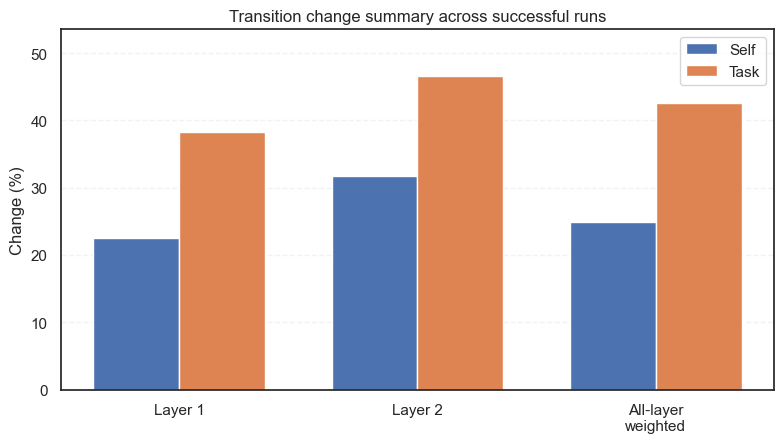

In [16]:
#!/usr/bin/env python3
from pathlib import Path

# =========================
# ========= CONFIG ========
# =========================

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "AnalysisScripts":
    REPO_ROOT = REPO_ROOT.parent

MODELS_DIR = (
    REPO_ROOT
    / "Checkpoints_States_selectedGraphs"
    / "WalkSpinJump_relu"
).resolve()

# -------------------------
# MODE SELECT
# -------------------------
CACHE_XLSX_PATH = ""  # set to cache dir to LOAD; leave "" to COMPUTE

# -------------------------
# MULTI-RUN COMPUTE CONTROL
# -------------------------
MULTI_RUN_MODE = True
RUN_PATHS = [str(MODELS_DIR)]  # can be a models dir or a parent folder to search under
RECOMPUTE_OVERWRITE = True
CONTINUE_ON_RUN_ERROR = True
RUN_DISCOVERY_MAX_DEPTH = 2

# =========================
# === MODEL SOURCE CONFIG ==
# =========================
MULTI_CYCLE_MODE = True

MODEL_DIR = str(MODELS_DIR)
MODEL_PATH_LIST = ""

SINGLE_BEHAVIOR_MODEL_PATHS = {}
SINGLE_SEQUENCE_ID = "single_seq"

# =========================
# === GLOBAL STATE POOL ===
# =========================
ALL_STATES_PATH = str(
    (REPO_ROOT / "Checkpoints_States_selectedGraphs" / "StatesConcat" / "ALL_states_concat.npy").resolve()
)

N_ALL_STATES = 200_000
PLOT_INPUTS_SUMMARY = False

ANALYZE_NORM_INPUTS = True
INPUT_NORM_MODE = "none"  # "zscore" or "none"

# --- Layers to analyze (hidden layers) ---
LAYER_INDICES = [0, 1]

SEED = 0
EPS = 1e-8
MIN_STD = 1e-5
ACTIVATION = "relu"  # {"elu","relu","tanh"}

# alive-only control
ALIVE_ONLY_CLUSTERING = True

# =========================
# === BLOCK CONFIG ========
# =========================
TAU = 0.70
BD_MIN_BLOCK_SIZE = 1

# =========================
# === ROBUST LOAD CONFIG ==
# =========================
ALLOW_UNSAFE_TORCH_LOAD = True
SKIP_BAD_CYCLES = True
MIN_CKPT_BYTES = 0
DEVICE = "cpu"

# ---- quick sanity prints ----
print("CWD          =", Path.cwd().resolve())
print("REPO_ROOT    =", REPO_ROOT)
print("MODELS_DIR   =", MODELS_DIR, "| exists:", MODELS_DIR.is_dir())
print("ALL_STATES   =", ALL_STATES_PATH, "| exists:", Path(ALL_STATES_PATH).is_file())

# =========================
# ======== IMPORTS ========
# =========================

import os
import gc
import glob
import pickle
import shutil
import traceback

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from scipy.optimize import linear_sum_assignment
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import reverse_cuthill_mckee, connected_components

# =========================
# ======== HELPERS ========
# =========================

def _seed_everything(seed: int):
    import random
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def _torch_load_compat(path: str):
    if MIN_CKPT_BYTES and os.path.exists(path):
        try:
            sz = os.path.getsize(path)
            if sz < MIN_CKPT_BYTES:
                raise RuntimeError(f"Checkpoint too small ({sz} bytes) < MIN_CKPT_BYTES={MIN_CKPT_BYTES}")
        except OSError:
            pass

    try:
        return torch.load(path, map_location="cpu", weights_only=True)
    except TypeError:
        return torch.load(path, map_location="cpu")
    except (pickle.UnpicklingError, RuntimeError, EOFError, ValueError):
        if not ALLOW_UNSAFE_TORCH_LOAD:
            raise
        try:
            return torch.load(path, map_location="cpu", weights_only=False)
        except TypeError:
            return torch.load(path, map_location="cpu")

def _load_rlg_forplay_state_dict(path: str) -> dict:
    payload = _torch_load_compat(path)
    if isinstance(payload, dict) and "model" in payload and isinstance(payload["model"], dict):
        sd = {}
        for k, v in payload["model"].items():
            sd[k] = v.detach().cpu().clone() if torch.is_tensor(v) else v
        return sd
    raise ValueError(f"[ckpt] {path} missing 'model' dict (for-play).")

def _try_load_sd(path: str):
    try:
        sd = _load_rlg_forplay_state_dict(path)
        return sd, None
    except Exception as e:
        return None, f"{type(e).__name__}: {e}"

def _discover_actor_mlp_layers(state_dict: dict):
    candidates = []
    for k in state_dict.keys():
        if k.endswith(".weight") and ("actor_mlp" in k or ".actor." in k or "actor_net" in k or "actor.trunk" in k):
            parts = k.split(".")
            try:
                idx = int(parts[-2])
                bias_key = k[:-6] + "bias"
                if bias_key in state_dict:
                    candidates.append((idx, k, bias_key))
            except Exception:
                candidates.append((10**6, k, k[:-6] + "bias"))
    candidates.sort(key=lambda t: (t[0], t[1]))
    return candidates

def _first_linear_in(actor_layers, sd):
    if not actor_layers:
        raise RuntimeError("No actor MLP layers found.")
    _, wkey, _ = actor_layers[0]
    W = sd[wkey]
    if isinstance(W, torch.Tensor):
        W = W.detach().cpu().numpy()
    if W.ndim != 2:
        raise RuntimeError(f"Unexpected weight shape for {wkey}: {tuple(W.shape)}")
    return W.shape[1], W.shape[0]

def _activation(x: np.ndarray, name: str) -> np.ndarray:
    if name == "elu":
        y = x.copy()
        neg = x <= 0
        y[neg] = np.expm1(x[neg])
        return y
    if name == "relu":
        return np.maximum(0.0, x)
    if name == "tanh":
        return np.tanh(x)
    raise ValueError(f"Unsupported ACTIVATION '{name}'")

def _zscore_cols(X: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    if X.size == 0:
        return X.astype(np.float32, copy=False)
    mu = X.mean(axis=0, keepdims=True)
    sd = X.std(axis=0, keepdims=True)
    sd = np.where(sd < 1e-12, 1.0, sd)
    return ((X - mu) / (sd + eps)).astype(np.float32, copy=False)

def _dead_alive_indices(acts_post: np.ndarray, min_std: float):
    if acts_post.size == 0:
        return np.array([], dtype=int), np.array([], dtype=int)
    sd = acts_post.std(axis=0)
    dead_mask = sd <= min_std
    dead_idx = np.where(dead_mask)[0].astype(int)
    alive_idx = np.where(~dead_mask)[0].astype(int)
    return dead_idx, alive_idx

def corr_matrix(X):
    X = np.asarray(X, dtype=np.float32)
    if X.ndim != 2:
        raise ValueError("corr_matrix expects 2D array (T, N)")
    n = X.shape[1]
    if n == 0:
        return np.zeros((0, 0), np.float32)
    if n == 1:
        return np.ones((1, 1), np.float32)

    norms = np.linalg.norm(X, axis=0, keepdims=True).astype(np.float64)
    norms = np.where(norms < 1e-12, 1.0, norms)
    Xn = X.astype(np.float64, copy=False) / norms

    S = Xn.T @ Xn
    S = np.nan_to_num(S, nan=0.0, posinf=0.0, neginf=0.0)
    S = np.clip(S, -1.0, 1.0)
    np.fill_diagonal(S, 1.0)
    return S.astype(np.float32, copy=False)

def hungarian_match_cosine(A, B, eps=1e-8):
    A = np.asarray(A, dtype=np.float32)
    B = np.asarray(B, dtype=np.float32)

    if A.size == 0 or B.size == 0:
        sim = np.zeros((A.shape[1] if A.ndim == 2 else 0, B.shape[1] if B.ndim == 2 else 0), dtype=np.float32)
        return sim, np.array([], dtype=int), np.array([], dtype=int), np.array([], dtype=float)

    nA = np.linalg.norm(A, axis=0, keepdims=True)
    nB = np.linalg.norm(B, axis=0, keepdims=True)
    nA[nA < eps] = 1.0
    nB[nB < eps] = 1.0

    sim = (A.T @ B) / (nA.T @ nB)
    sim = np.nan_to_num(sim)
    sim = np.clip(sim, -1.0, 1.0)

    i_idx, j_idx = linear_sum_assignment(-sim)
    matched_vals = sim[i_idx, j_idx] if i_idx.size else np.array([], dtype=float)
    return sim, i_idx, j_idx, matched_vals

def _actor_hidden_forward_numpy(X, actor_layers, sd, activation_name):
    outs = []
    h = X
    for _, wkey, bkey in actor_layers:
        W = sd[wkey]
        if isinstance(W, torch.Tensor):
            W = W.detach().cpu().numpy()
        b = sd[bkey]
        if isinstance(b, torch.Tensor):
            b = b.detach().cpu().numpy()
        h = h @ W.T + b[None, :]
        h = _activation(h, activation_name)
        outs.append(h.astype(np.float32, copy=False))
    return outs

def get_layer_output_batch_from_ckpt(sd, inputs: torch.Tensor, layer_idx: int, actor_layers, activation_name):
    X = inputs.detach().cpu().numpy().astype(np.float32, copy=False)
    outs = _actor_hidden_forward_numpy(X, actor_layers, sd, activation_name)
    if layer_idx < 0 or layer_idx >= len(outs):
        raise IndexError(f"layer_idx={layer_idx} out of range (0..{len(outs)-1})")
    return outs[layer_idx]

def _safe_corr(a, b, eps: float = 1e-8):
    a = np.asarray(a, dtype=np.float32).ravel()
    b = np.asarray(b, dtype=np.float32).ravel()
    if a.size != b.size or a.size == 0:
        return 0.0
    na = float(np.linalg.norm(a))
    nb = float(np.linalg.norm(b))
    if na < eps or nb < eps:
        return 0.0
    c = float((a.astype(np.float64) @ b.astype(np.float64)) / (na * nb))
    if not np.isfinite(c):
        return 0.0
    c = max(-1.0, min(1.0, c))
    return float(abs(c))

def _order_by_cluster_size(labels, base_order=None):
    labels = np.asarray(labels)
    n = labels.size
    if n == 0:
        return np.arange(0, dtype=int)
    if base_order is None:
        base_order = np.arange(n, dtype=int)
    base_order = np.asarray(base_order)

    unique_cids = np.unique(labels)
    sizes = [int(np.sum(labels == cid)) for cid in unique_cids]
    sorted_cids = [cid for cid, _ in sorted(zip(unique_cids, sizes), key=lambda t: -t[1])]

    labels_in_base = labels[base_order]
    new_order_list = []
    for cid in sorted_cids:
        new_order_list.append(base_order[labels_in_base == cid])
    return np.concatenate(new_order_list) if new_order_list else np.arange(n, dtype=int)

def _relabel_clusters_by_size(labels):
    labels = np.asarray(labels)
    if labels.size == 0:
        return labels.astype(int)
    unique_cids, counts = np.unique(labels, return_counts=True)
    order = np.argsort(-counts)
    sorted_cids = unique_cids[order]
    cid_to_rank = {cid: rank + 1 for rank, cid in enumerate(sorted_cids)}
    return np.array([cid_to_rank[c] for c in labels], dtype=int)

def _plot_inputs_summary(X: np.ndarray, title: str = "Sampled inputs"):
    mu = X.mean(axis=0)
    sd = X.std(axis=0)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(mu, bins=60)
    axes[0].set_title("Per-dim mean histogram")
    axes[0].set_xlabel("mean")
    axes[0].set_ylabel("count")

    axes[1].hist(sd, bins=60)
    axes[1].set_title("Per-dim std histogram")
    axes[1].set_xlabel("std")
    axes[1].set_ylabel("count")

    fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()

# =========================
# === BLOCK DIAGONALISATION
# =========================

def blockdiag_rcm_blocks_from_abs(R_abs: np.ndarray, tau: float, min_block_size: int):
    R_abs = np.asarray(R_abs, dtype=np.float32)
    n = int(R_abs.shape[0])
    if n == 0:
        return np.array([], dtype=int), np.array([], dtype=int)
    if n == 1:
        return np.array([0], dtype=int), np.array([1], dtype=int)

    R_abs = 0.5 * (R_abs + R_abs.T)
    R_abs = np.clip(R_abs, 0.0, 1.0)
    np.fill_diagonal(R_abs, 0.0)

    tau = float(max(0.0, min(1.0, tau)))
    A = (R_abs >= tau).astype(np.int8)
    np.fill_diagonal(A, 0)
    G = csr_matrix(A)

    n_comp, comp0 = connected_components(G, directed=False, connection="weak")
    comp = comp0.copy()

    if min_block_size is not None and int(min_block_size) > 1:
        sizes = np.bincount(comp, minlength=n_comp)
        small = np.where(sizes < int(min_block_size))[0]
        if small.size:
            comp[np.isin(comp, small)] = -1
            keep = [c for c in np.unique(comp) if c != -1]
            remap = {c: i for i, c in enumerate(keep)}
            comp2 = np.empty(n, dtype=int)
            for i in range(n):
                c = comp[i]
                comp2[i] = remap[c] if c != -1 else len(keep)
            comp = comp2
            n_comp = int(comp.max()) + 1

    sizes = [(c, int(np.sum(comp == c))) for c in range(n_comp)]
    sizes.sort(key=lambda t: -t[1])

    parts = []
    for c, _ in sizes:
        idxs = np.where(comp == c)[0]
        if idxs.size <= 2:
            parts.append(idxs)
        else:
            subG = G[idxs][:, idxs]
            sub_ord = reverse_cuthill_mckee(subG, symmetric_mode=True)
            parts.append(idxs[np.asarray(sub_ord, dtype=int)])

    order = np.concatenate(parts).astype(int)
    labels_1based = (comp + 1).astype(int)
    return order, labels_1based

# =========================
# === MULTI-RUN IO ========
# =========================

def _looks_like_models_dir(d: str) -> bool:
    if not os.path.isdir(d):
        return False
    return len(glob.glob(os.path.join(d, "*_for_play.pth"))) > 0

def _resolve_models_dir(p: str):
    if not p:
        return None
    p = os.path.expanduser(os.path.expandvars(str(p).strip()))
    if not p:
        return None

    if os.path.isfile(p):
        d = os.path.dirname(p)
        if os.path.basename(d) == "models":
            return d
        if _looks_like_models_dir(d):
            return d
        return None

    if not os.path.isdir(p):
        return None

    base = os.path.basename(p)

    if base == "transition_change_cache":
        md = os.path.dirname(p)
        if os.path.basename(md) == "models":
            return md

    if base == "models":
        return p

    md = os.path.join(p, "models")
    if os.path.isdir(md):
        return md

    md2 = os.path.join(p, "organized", "models")
    if os.path.isdir(md2):
        return md2

    return None

def _discover_models_dirs_under_parent(parent: str, max_depth: int = 2):
    parent = os.path.expanduser(os.path.expandvars(str(parent).strip()))
    if not os.path.isdir(parent):
        return []

    found = set()
    parent_depth = parent.rstrip(os.sep).count(os.sep)

    for root, dirs, _ in os.walk(parent):
        depth = root.count(os.sep) - parent_depth
        if depth > max_depth:
            dirs[:] = []
            continue

        if os.path.basename(root) == "models":
            found.add(root)

        if "models" in dirs:
            found.add(os.path.join(root, "models"))

        if "organized" in dirs:
            cand = os.path.join(root, "organized", "models")
            if os.path.isdir(cand):
                found.add(cand)

    out = []
    for d in sorted(found):
        if _looks_like_models_dir(d):
            out.append(d)
    return out

def _expand_run_inputs(run_paths, max_depth=2):
    model_dirs = []
    for p in run_paths:
        p = os.path.expanduser(os.path.expandvars(str(p).strip()))
        if not p:
            continue
        md = _resolve_models_dir(p)
        if md is not None and _looks_like_models_dir(md):
            model_dirs.append(md)
            continue
        if os.path.isdir(p):
            model_dirs.extend(_discover_models_dirs_under_parent(p, max_depth=max_depth))
    return sorted(set(model_dirs))

def _clear_existing_cache(cache_root: str):
    if not os.path.isdir(cache_root):
        return
    for fn in [
        "transition_change_rows.csv",
        "transition_change_summary.csv",
    ]:
        fp = os.path.join(cache_root, fn)
        if os.path.exists(fp):
            try:
                os.remove(fp)
            except Exception:
                pass

# =========================
# === GLOBAL STATES =======
# =========================

_STATES_CACHE = {}  # obs_dim -> dict(ref_inputs, combined_states)

def _get_ref_inputs_for_obs_dim(obs_dim: int):
    global _STATES_CACHE
    if obs_dim in _STATES_CACHE:
        return _STATES_CACHE[obs_dim]["ref_inputs"], _STATES_CACHE[obs_dim]["combined_states"]

    if not os.path.exists(ALL_STATES_PATH):
        raise FileNotFoundError(f"[states] missing: {ALL_STATES_PATH}")

    print(f"[STATES] Loading ALL states for obs_dim={obs_dim} ...")
    all_states = np.load(ALL_STATES_PATH)
    if all_states.ndim != 2 or all_states.shape[1] != obs_dim:
        raise ValueError(f"[states] {ALL_STATES_PATH} has shape {all_states.shape}, expected (*,{obs_dim})")

    n_avail = all_states.shape[0]
    if n_avail >= N_ALL_STATES:
        idx = np.random.choice(n_avail, size=N_ALL_STATES, replace=False)
        combined_states = all_states[idx].astype(np.float32, copy=False)
    else:
        idx = np.random.choice(n_avail, size=N_ALL_STATES, replace=True)
        combined_states = all_states[idx].astype(np.float32, copy=False)

    print(f"[STATES] loaded: {all_states.shape}, sampled: {combined_states.shape}")

    if PLOT_INPUTS_SUMMARY:
        _plot_inputs_summary(combined_states, title=f"Sampled inputs (N={N_ALL_STATES})")

    if ANALYZE_NORM_INPUTS and INPUT_NORM_MODE == "zscore":
        mu_in = combined_states.mean(axis=0, keepdims=True)
        sd_in = combined_states.std(axis=0, keepdims=True)
        combined_states = (combined_states - mu_in) / (sd_in + 1e-8)
        print("[STATES] applied input z-score normalization")
    else:
        print("[STATES] input normalization disabled")

    ref_inputs = torch.as_tensor(combined_states, dtype=torch.float32, device=DEVICE)

    _STATES_CACHE[obs_dim] = {
        "ref_inputs": ref_inputs,
        "combined_states": combined_states,
    }
    return ref_inputs, combined_states

# =========================
# === DISCOVERY ===========
# =========================

def _parse_ckpt_meta_from_filename(path: str):
    base = os.path.basename(path)
    if not base.endswith("_for_play.pth"):
        return None
    parts = base.split("_")
    if len(parts) < 3:
        return None

    cycle_id = parts[0]
    b_id = parts[1].lower()
    behavior = parts[2].lower()

    if behavior not in ("walk", "jump", "spin"):
        return None
    if not b_id.startswith("b"):
        return None

    cycle_digits = "".join(ch for ch in cycle_id if ch.isdigit())
    b_digits = "".join(ch for ch in b_id if ch.isdigit())
    cycle_num = int(cycle_digits) if cycle_digits else 0
    b_num = int(b_digits) if b_digits else 0

    ckpt_id = base[:-len("_for_play.pth")]

    return {
        "cycle_id": cycle_id,
        "cycle_num": cycle_num,
        "b_id": b_id,
        "b_num": b_num,
        "behavior": behavior,
        "ckpt_id": ckpt_id,
    }

def _discover_forplay_models_global(model_dir: str | None, model_path_list: str | None):
    paths = []
    if model_path_list is not None and str(model_path_list).strip():
        for token in str(model_path_list).split():
            token = token.strip()
            if token.endswith("_for_play.pth"):
                paths.append(token)
    if model_dir is not None and str(model_dir).strip():
        pattern = os.path.join(str(model_dir), "*_for_play.pth")
        paths.extend(glob.glob(pattern))
    paths = sorted(set(paths))
    if not paths:
        raise RuntimeError("No *_for_play.pth models found from model_dir / MODEL_PATH_LIST.")

    items = []
    for p in paths:
        meta = _parse_ckpt_meta_from_filename(p)
        if meta is None:
            print(f"[warn] Skipping unrecognized filename: {os.path.basename(p)}")
            continue
        items.append({**meta, "path": p})

    if not items:
        raise RuntimeError("No recognized (walk/jump/spin) checkpoints found.")

    items.sort(key=lambda d: (d["cycle_num"], d["cycle_id"], d["b_num"], d["b_id"], os.path.basename(d["path"])))

    beh_counts = {}
    seq_all = []
    for gi, d in enumerate(items):
        beh = d["behavior"]
        beh_counts[beh] = beh_counts.get(beh, 0) + 1
        seq_all.append({
            "ckpt_id": d["ckpt_id"],
            "cycle_id": d["cycle_id"],
            "behavior": beh,
            "path": d["path"],
            "global_idx": int(gi),
            "beh_seq_idx": int(beh_counts[beh] - 1),
        })

    return seq_all, paths

def _infer_obs_dim_from_any_path(path_list):
    for p in path_list:
        if not os.path.exists(p):
            continue
        sd, _ = _try_load_sd(p)
        if sd is None:
            continue
        layers = _discover_actor_mlp_layers(sd)
        if not layers:
            continue
        obs_dim, _ = _first_linear_in(layers, sd)
        return obs_dim, p
    raise RuntimeError("Could not infer obs_dim: no loadable model found.")

def _sequence_from_single_behavior_paths(single_paths_by_beh: dict, seq_id_prefix: str = "single"):
    order = ["walk", "spin", "jump"]
    flat = []
    for beh in order:
        if beh not in single_paths_by_beh:
            continue
        lst = single_paths_by_beh[beh]
        if not isinstance(lst, (list, tuple)) or len(lst) == 0:
            continue
        for i, p in enumerate(lst):
            p = os.path.expanduser(os.path.expandvars(str(p)))
            if not os.path.exists(p):
                raise FileNotFoundError(f"[single:{beh}] missing: {p}")
            flat.append({
                "ckpt_id": f"{seq_id_prefix}{i:04d}_{beh}",
                "cycle_id": f"{seq_id_prefix}{i:04d}",
                "behavior": beh,
                "path": p,
                "global_idx": len(flat),
                "beh_seq_idx": i,
            })
    if not flat:
        raise RuntimeError("SINGLE_BEHAVIOR_MODEL_PATHS is empty / invalid.")
    return flat

# =========================
# === SUMMARY HELPERS =====
# =========================

def _weighted_mean(vals, weights):
    vals = np.asarray(vals, dtype=float)
    weights = np.asarray(weights, dtype=float)
    mask = np.isfinite(vals) & np.isfinite(weights) & (weights > 0)
    if not np.any(mask):
        return np.nan
    return float(np.sum(vals[mask] * weights[mask]) / np.sum(weights[mask]))

def _summarize_transition_rows(df_rows: pd.DataFrame, run_name: str, models_dir: str):
    rows = []

    if df_rows is None or len(df_rows) == 0:
        for key, layer_idx in [("layer0", 0), ("layer1", 1), ("all", -1)]:
            rows.append({
                "run_name": run_name,
                "models_dir": models_dir,
                "summary_scope": key,
                "layer_idx": layer_idx,
                "n_transitions": 0,
                "self_change_percent": np.nan,
                "task_change_percent": np.nan,
                "self_weight_total": 0,
                "task_weight_total": 0,
            })
        return pd.DataFrame(rows)

    # per-layer summaries
    for L in sorted(df_rows["layer_idx"].unique().tolist()):
        sub = df_rows[df_rows["layer_idx"] == L].copy()
        rows.append({
            "run_name": run_name,
            "models_dir": models_dir,
            "summary_scope": f"layer{L}",
            "layer_idx": int(L),
            "n_transitions": int(sub["transition_id"].nunique()),
            "self_change_percent": _weighted_mean(sub["self_change_percent"], sub["self_n_scored"]),
            "task_change_percent": _weighted_mean(sub["task_change_percent"], sub["task_n_scored"]),
            "self_weight_total": int(np.nansum(sub["self_n_scored"])),
            "task_weight_total": int(np.nansum(sub["task_n_scored"])),
        })

    # all-layer weighted summary
    rows.append({
        "run_name": run_name,
        "models_dir": models_dir,
        "summary_scope": "all",
        "layer_idx": -1,
        "n_transitions": int(df_rows["transition_id"].nunique()),
        "self_change_percent": _weighted_mean(df_rows["self_change_percent"], df_rows["self_n_scored"]),
        "task_change_percent": _weighted_mean(df_rows["task_change_percent"], df_rows["task_n_scored"]),
        "self_weight_total": int(np.nansum(df_rows["self_n_scored"])),
        "task_weight_total": int(np.nansum(df_rows["task_n_scored"])),
    })

    return pd.DataFrame(rows)

def _print_run_summary(df_summary: pd.DataFrame, run_name: str):
    if df_summary is None or len(df_summary) == 0:
        print(f"[SUMMARY] {run_name}: no rows")
        return

    print("\n" + "=" * 90)
    print(f"TRANSITION CHANGE SUMMARY — {run_name}")
    print("=" * 90)

    for scope in ["layer0", "layer1", "all"]:
        sub = df_summary[df_summary["summary_scope"] == scope]
        if len(sub) == 0:
            continue
        r = sub.iloc[0]
        label = "Layer 1" if scope == "layer0" else ("Layer 2" if scope == "layer1" else "ALL-LAYER WEIGHTED")
        print(label)
        print(f"  transitions: {int(r['n_transitions'])}")
        print(f"  SELF change: {r['self_change_percent']:.2f}%" if np.isfinite(r["self_change_percent"]) else "  SELF change: nan")
        print(f"  TASK change: {r['task_change_percent']:.2f}%" if np.isfinite(r["task_change_percent"]) else "  TASK change: nan")
        print("-" * 90)

# =========================
# === PLOTTING ============
# =========================

def plot_transition_change_summary(df_summary: pd.DataFrame, title: str):
    if df_summary is None or len(df_summary) == 0:
        print("[PLOT] No summary rows to plot.")
        return

    order = ["layer0", "layer1", "all"]
    labels = ["Layer 1", "Layer 2", "All-layer\nweighted"]

    xs = np.arange(len(order))
    self_vals = []
    task_vals = []

    for scope in order:
        sub = df_summary[df_summary["summary_scope"] == scope]
        if len(sub) == 0:
            self_vals.append(np.nan)
            task_vals.append(np.nan)
        else:
            self_vals.append(float(sub.iloc[0]["self_change_percent"]))
            task_vals.append(float(sub.iloc[0]["task_change_percent"]))

    width = 0.36
    fig, ax = plt.subplots(figsize=(8.0, 4.6))

    ax.bar(xs - width / 2, self_vals, width=width, label="Self")
    ax.bar(xs + width / 2, task_vals, width=width, label="Task")

    ax.set_xticks(xs)
    ax.set_xticklabels(labels)
    ax.set_ylabel("Change (%)")
    ax.set_title(title)
    ax.grid(True, axis="y", alpha=0.25, linestyle="--")
    ax.legend()

    ymax = 0.0
    for v in self_vals + task_vals:
        if np.isfinite(v):
            if v > ymax:
                ymax = float(v)
    ax.set_ylim(0.0, max(5.0, 1.15 * ymax))

    plt.tight_layout()
    plt.show()

# =========================
# === CORE COMPUTE ========
# =========================

def compute_transition_change_cache_for_one_models_dir(model_dir: str, overwrite_cache: bool = True):
    if MULTI_CYCLE_MODE:
        if not str(model_dir).strip():
            raise RuntimeError("model_dir is empty (needed when MULTI_CYCLE_MODE=True).")
        model_dir = os.path.expanduser(os.path.expandvars(model_dir))
        if not os.path.isdir(model_dir):
            raise FileNotFoundError(f"model_dir not found: {model_dir}")

        run_root = os.path.dirname(model_dir)
        run_name = os.path.basename(run_root)

        seq_all, all_paths = _discover_forplay_models_global(model_dir, MODEL_PATH_LIST)
    else:
        seq_all = _sequence_from_single_behavior_paths(SINGLE_BEHAVIOR_MODEL_PATHS, seq_id_prefix=SINGLE_SEQUENCE_ID)
        any_path = seq_all[0]["path"]
        model_dir = os.path.dirname(os.path.expanduser(os.path.expandvars(any_path)))
        run_root = os.path.dirname(model_dir)
        run_name = os.path.basename(run_root) if run_root else "single_run"
        all_paths = [d["path"] for d in seq_all]

    cache_root = os.path.join(model_dir, "transition_change_cache")

    if overwrite_cache and os.path.isdir(cache_root):
        print(f"[CACHE] Overwrite enabled -> clearing old cache:\n  {cache_root}")
        _clear_existing_cache(cache_root)

    os.makedirs(cache_root, exist_ok=True)

    behaviors_present = sorted(set(d["behavior"] for d in seq_all))

    print("\n" + "=" * 100)
    print(f"[RUN] {run_name}")
    print(f"      models_dir: {model_dir}")
    print(f"      cache_root: {cache_root}")
    print(f"      MULTI_CYCLE_MODE={MULTI_CYCLE_MODE}")
    print(f"      MODE: one-sided source->target transition change")
    print(f"      checkpoints: {len(seq_all)}  behaviors: {behaviors_present}")
    print(f"      transitions used: adjacent ONLY, behavior-changing ONLY (t -> t+1)")
    print(f"      blockdiag: abs-tau + CC + RCM  |  TAU={TAU:.2f}  BD_MIN_BLOCK_SIZE={BD_MIN_BLOCK_SIZE}")
    print(f"      modules: self=largest source block, task=all other source blocks merged")
    print("=" * 100)

    obs_dim, obs_dim_src = _infer_obs_dim_from_any_path(all_paths)
    print(f"[INFO] Obs dim inferred from: {os.path.basename(obs_dim_src)}  -> {obs_dim}")

    ref_inputs, _ = _get_ref_inputs_for_obs_dim(obs_dim)

    transition_rows = []
    skipped_items = []
    n_total = len(seq_all)

    transition_counter = 0

    for t in range(n_total - 1):
        src = seq_all[t]
        tgt = seq_all[t + 1]

        # only behavior-changing adjacent transitions
        if str(src["behavior"]) == str(tgt["behavior"]):
            continue

        src_id = src["ckpt_id"]
        tgt_id = tgt["ckpt_id"]
        src_beh = src["behavior"]
        tgt_beh = tgt["behavior"]
        src_path = src["path"]
        tgt_path = tgt["path"]

        transition_counter += 1
        transition_id = f"{src_id}__TO__{tgt_id}"

        print("\n" + "-" * 100)
        print(f"[TRANSITION] {transition_counter}: {src_beh}:{src_id}  ->  {tgt_beh}:{tgt_id}")

        if not os.path.exists(src_path):
            msg = f"missing source file: {src_path}"
            print(f"[warn] Skipping transition {transition_id}: {msg}")
            skipped_items.append((transition_id, msg))
            if SKIP_BAD_CYCLES:
                continue
            raise RuntimeError(msg)

        if not os.path.exists(tgt_path):
            msg = f"missing target file: {tgt_path}"
            print(f"[warn] Skipping transition {transition_id}: {msg}")
            skipped_items.append((transition_id, msg))
            if SKIP_BAD_CYCLES:
                continue
            raise RuntimeError(msg)

        sd_src, err_src = _try_load_sd(src_path)
        if sd_src is None:
            msg = f"failed source load: {os.path.basename(src_path)} | {err_src}"
            print(f"[warn] Skipping transition {transition_id}: {msg}")
            skipped_items.append((transition_id, msg))
            if SKIP_BAD_CYCLES:
                continue
            raise RuntimeError(msg)

        sd_tgt, err_tgt = _try_load_sd(tgt_path)
        if sd_tgt is None:
            msg = f"failed target load: {os.path.basename(tgt_path)} | {err_tgt}"
            print(f"[warn] Skipping transition {transition_id}: {msg}")
            skipped_items.append((transition_id, msg))
            if SKIP_BAD_CYCLES:
                continue
            raise RuntimeError(msg)

        layers_src = _discover_actor_mlp_layers(sd_src)
        layers_tgt = _discover_actor_mlp_layers(sd_tgt)
        if not layers_src:
            msg = f"source has no actor layers: {os.path.basename(src_path)}"
            print(f"[warn] Skipping transition {transition_id}: {msg}")
            skipped_items.append((transition_id, msg))
            if SKIP_BAD_CYCLES:
                continue
            raise RuntimeError(msg)
        if not layers_tgt:
            msg = f"target has no actor layers: {os.path.basename(tgt_path)}"
            print(f"[warn] Skipping transition {transition_id}: {msg}")
            skipped_items.append((transition_id, msg))
            if SKIP_BAD_CYCLES:
                continue
            raise RuntimeError(msg)

        obs_dim_src, _ = _first_linear_in(layers_src, sd_src)
        obs_dim_tgt, _ = _first_linear_in(layers_tgt, sd_tgt)
        if obs_dim_src != obs_dim or obs_dim_tgt != obs_dim:
            msg = f"obs_dim mismatch src={obs_dim_src}, tgt={obs_dim_tgt}, global={obs_dim}"
            print(f"[warn] Skipping transition {transition_id}: {msg}")
            skipped_items.append((transition_id, msg))
            if SKIP_BAD_CYCLES:
                continue
            raise RuntimeError(msg)

        for layer_idx in LAYER_INDICES:
            acts_src_full = get_layer_output_batch_from_ckpt(sd_src, ref_inputs, layer_idx, layers_src, ACTIVATION)
            acts_tgt_full = get_layer_output_batch_from_ckpt(sd_tgt, ref_inputs, layer_idx, layers_tgt, ACTIVATION)

            dead_src, alive_src = _dead_alive_indices(acts_src_full, MIN_STD)
            dead_tgt, alive_tgt = _dead_alive_indices(acts_tgt_full, MIN_STD)

            if ALIVE_ONLY_CLUSTERING:
                acts_src = acts_src_full[:, alive_src] if alive_src.size else acts_src_full[:, :0]
                acts_tgt = acts_tgt_full[:, alive_tgt] if alive_tgt.size else acts_tgt_full[:, :0]
            else:
                acts_src = acts_src_full
                acts_tgt = acts_tgt_full

            A_src = _zscore_cols(acts_src, eps=EPS) if acts_src.size else acts_src.astype(np.float32, copy=False)
            A_tgt = _zscore_cols(acts_tgt, eps=EPS) if acts_tgt.size else acts_tgt.astype(np.float32, copy=False)

            n_src_alive = int(A_src.shape[1])
            n_tgt_alive = int(A_tgt.shape[1])

            R_src = corr_matrix(A_src)
            R_tgt = corr_matrix(A_tgt)

            R_src_abs = np.abs(R_src)
            order0, labels0 = blockdiag_rcm_blocks_from_abs(R_src_abs, tau=TAU, min_block_size=BD_MIN_BLOCK_SIZE)
            labels_src = _relabel_clusters_by_size(labels0)
            order_src = _order_by_cluster_size(labels_src, base_order=order0)

            _, i_idx, j_idx, _ = hungarian_match_cosine(A_src, A_tgt)

            act_by_src = np.full(n_src_alive, np.nan, dtype=np.float32)
            conn_by_src = np.full(n_src_alive, np.nan, dtype=np.float32)
            pers_by_src = np.full(n_src_alive, np.nan, dtype=np.float32)

            if i_idx.size:
                i_idx = i_idx.astype(int, copy=False)
                j_idx = j_idx.astype(int, copy=False)

                R_src_sub = R_src[np.ix_(i_idx, i_idx)].astype(np.float32, copy=True)
                R_tgt_sub = R_tgt[np.ix_(j_idx, j_idx)].astype(np.float32, copy=True)
                np.fill_diagonal(R_src_sub, 0.0)
                np.fill_diagonal(R_tgt_sub, 0.0)

                dot = np.sum(R_src_sub.astype(np.float64) * R_tgt_sub.astype(np.float64), axis=1)
                den = (
                    np.linalg.norm(R_src_sub, axis=1).astype(np.float64)
                    * np.linalg.norm(R_tgt_sub, axis=1).astype(np.float64)
                    + EPS
                )
                conn_rows = np.abs(dot / den).astype(np.float32, copy=False)

                for p, (isrc, jtgt) in enumerate(zip(i_idx, j_idx)):
                    a = float(_safe_corr(A_src[:, isrc], A_tgt[:, jtgt], eps=EPS))
                    c = float(conn_rows[p])
                    act_by_src[isrc] = a
                    conn_by_src[isrc] = c
                    pers_by_src[isrc] = 0.5 * (a + c)

            self_mask = (labels_src == 1) if labels_src.size else np.zeros((n_src_alive,), dtype=bool)
            task_mask = (labels_src != 1) if labels_src.size else np.zeros((n_src_alive,), dtype=bool)

            def _mean_or_nan(x, mask):
                vals = x[mask]
                vals = vals[np.isfinite(vals)]
                return float(np.mean(vals)) if vals.size else np.nan

            def _count_finite(x, mask):
                vals = x[mask]
                return int(np.isfinite(vals).sum())

            self_pers = _mean_or_nan(pers_by_src, self_mask)
            task_pers = _mean_or_nan(pers_by_src, task_mask)

            self_change = float(100.0 * (1.0 - self_pers)) if np.isfinite(self_pers) else np.nan
            task_change = float(100.0 * (1.0 - task_pers)) if np.isfinite(task_pers) else np.nan

            transition_rows.append({
                "run_name": run_name,
                "models_dir": model_dir,
                "transition_id": transition_id,
                "source_global_idx": int(src["global_idx"]),
                "target_global_idx": int(tgt["global_idx"]),
                "source_seq_id": str(src_id),
                "target_seq_id": str(tgt_id),
                "source_cycle_id": str(src["cycle_id"]),
                "target_cycle_id": str(tgt["cycle_id"]),
                "source_behavior": str(src_beh),
                "target_behavior": str(tgt_beh),
                "transition_label": f"{src_beh}->{tgt_beh}",
                "layer_idx": int(layer_idx),

                "n_source_total": int(acts_src_full.shape[1]),
                "n_target_total": int(acts_tgt_full.shape[1]),
                "n_source_alive": int(n_src_alive),
                "n_target_alive": int(n_tgt_alive),
                "n_source_dead": int(dead_src.size),
                "n_target_dead": int(dead_tgt.size),
                "n_matched_pairs": int(i_idx.size),
                "K_source": int(np.max(labels_src)) if labels_src.size else 0,

                "self_size_alive": int(np.sum(self_mask)),
                "self_n_scored": _count_finite(pers_by_src, self_mask),
                "self_mean_activation_stability": _mean_or_nan(act_by_src, self_mask),
                "self_mean_connectivity_stability": _mean_or_nan(conn_by_src, self_mask),
                "self_mean_persistence": self_pers,
                "self_change_percent": self_change,

                "task_size_alive": int(np.sum(task_mask)),
                "task_n_scored": _count_finite(pers_by_src, task_mask),
                "task_mean_activation_stability": _mean_or_nan(act_by_src, task_mask),
                "task_mean_connectivity_stability": _mean_or_nan(conn_by_src, task_mask),
                "task_mean_persistence": task_pers,
                "task_change_percent": task_change,
            })

            print(
                f"  Layer {layer_idx + 1} | "
                f"SELF change={self_change:.2f}% | "
                f"TASK change={task_change:.2f}% | "
                f"matched={int(i_idx.size)}"
            )

            del acts_src_full, acts_tgt_full
            gc.collect()

        gc.collect()

    df_rows = pd.DataFrame(transition_rows)
    df_summary = _summarize_transition_rows(df_rows, run_name=run_name, models_dir=model_dir)

    rows_csv = os.path.join(cache_root, "transition_change_rows.csv")
    summary_csv = os.path.join(cache_root, "transition_change_summary.csv")
    df_rows.to_csv(rows_csv, index=False)
    df_summary.to_csv(summary_csv, index=False)

    print("\n" + "-" * 100)
    print(f"[DONE] Wrote CSV cache:\n  {rows_csv}\n  {summary_csv}")

    if skipped_items:
        print("\n[INFO] Skipped transitions:")
        for tid, reason in skipped_items:
            print(f"  - {tid}: {reason}")

    _print_run_summary(df_summary, run_name=run_name)

    print(f"\nTo reload this run later without recompute, set:")
    print(f'  CACHE_XLSX_PATH = r"{cache_root}"')

    return {
        "run_name": run_name,
        "models_dir": model_dir,
        "cache_root": cache_root,
        "behaviors": behaviors_present,
        "n_checkpoints_total": int(len(seq_all)),
        "n_transitions_used": int(df_rows["transition_id"].nunique()) if len(df_rows) else 0,
        "n_rows": int(len(df_rows)),
        "n_skipped": int(len(skipped_items)),
        "df_rows": df_rows,
        "df_summary": df_summary,
    }

# =========================
# === CACHE LOAD ==========
# =========================

def _load_rows_from_cache_root(cache_root: str) -> pd.DataFrame:
    rows_csv = os.path.join(cache_root, "transition_change_rows.csv")
    if not os.path.exists(rows_csv):
        raise FileNotFoundError(f"transition_change_rows.csv missing in cache_root: {cache_root}")
    return pd.read_csv(rows_csv)

def _load_summary_from_cache_root(cache_root: str) -> pd.DataFrame:
    summary_csv = os.path.join(cache_root, "transition_change_summary.csv")
    if not os.path.exists(summary_csv):
        raise FileNotFoundError(f"transition_change_summary.csv missing in cache_root: {cache_root}")
    return pd.read_csv(summary_csv)

def _aggregate_across_runs(df_rows_all: pd.DataFrame) -> pd.DataFrame:
    return _summarize_transition_rows(
        df_rows_all.copy(),
        run_name="ALL_RUNS",
        models_dir="MULTI_RUN_AGGREGATE",
    )

# =========================
# ========= MAIN ==========
# =========================

_seed_everything(SEED)

if str(CACHE_XLSX_PATH).strip():
    cache_root = os.path.expanduser(os.path.expandvars(str(CACHE_XLSX_PATH).strip()))
    if not os.path.isdir(cache_root):
        cache_root = os.path.dirname(cache_root)

    df_rows = _load_rows_from_cache_root(cache_root)
    df_summary = _load_summary_from_cache_root(cache_root)

    print(f"[CACHE] Loaded rows from: {cache_root}")
    _print_run_summary(df_summary, run_name=str(df_summary.iloc[0]['run_name']) if len(df_summary) else "cached_run")
    plot_transition_change_summary(df_summary, title="Transition change summary")

else:
    if MULTI_RUN_MODE:
        model_dirs = _expand_run_inputs(RUN_PATHS, max_depth=RUN_DISCOVERY_MAX_DEPTH)

        if not model_dirs:
            raise RuntimeError(
                "No run models dirs found.\n"
                "Check RUN_PATHS or increase RUN_DISCOVERY_MAX_DEPTH."
            )

        print("[BATCH] Will compute transition-change caches for these models dirs:")
        for i, d in enumerate(model_dirs, 1):
            print(f"  {i:02d}. {d}")

        successes = []
        failures = []

        for i, md in enumerate(model_dirs, 1):
            print("\n" + "=" * 100)
            print(f"[BATCH] Run {i}/{len(model_dirs)}")
            print("=" * 100)

            try:
                res = compute_transition_change_cache_for_one_models_dir(md, overwrite_cache=RECOMPUTE_OVERWRITE)
                successes.append(res)
            except Exception as e:
                tb = traceback.format_exc()
                print("\n" + "!" * 80)
                print(f"[ERROR] Failed run models_dir:\n  {md}")
                print(f"[ERROR] {type(e).__name__}: {e}")
                print("!" * 80)
                failures.append({
                    "models_dir": md,
                    "error": f"{type(e).__name__}: {e}",
                    "traceback": tb,
                })
                if not CONTINUE_ON_RUN_ERROR:
                    raise
            finally:
                plt.close("all")
                gc.collect()

        print("\n" + "=" * 100)
        print("[BATCH] DONE")
        print("=" * 100)

        print(f"✅ Successes: {len(successes)}")
        for s in successes:
            print(
                f"  - {s['run_name']} | transitions_used={s['n_transitions_used']} | "
                f"rows={s['n_rows']} | skipped={s['n_skipped']}"
            )
            print(f"    cache_root: {s['cache_root']}")

        if failures:
            print(f"\n❌ Failures: {len(failures)}")
            for f in failures:
                print(f"  - {f['models_dir']}")
                print(f"    {f['error']}")

        if successes:
            dfs = []
            for s in successes:
                if s["df_rows"] is not None and len(s["df_rows"]):
                    dfs.append(s["df_rows"])

            if dfs:
                df_rows_all = pd.concat(dfs, ignore_index=True)
                df_summary_all = _aggregate_across_runs(df_rows_all)

                print("\n" + "=" * 100)
                print("AGGREGATE ACROSS SUCCESSFUL RUNS")
                print("=" * 100)
                _print_run_summary(df_summary_all, run_name="ALL_RUNS")

                plot_transition_change_summary(
                    df_summary_all,
                    title="Transition change summary across successful runs"
                )

    else:
        res = compute_transition_change_cache_for_one_models_dir(MODEL_DIR, overwrite_cache=RECOMPUTE_OVERWRITE)
        plot_transition_change_summary(
            res["df_summary"],
            title=f"Transition change summary — {res['run_name']}"
        )

In [1]:
# ============================================================
# === LOAD ALL transition_change_cache FILES UNDER A FOLDER
# === FILTER TO SOURCE CYCLE > N
# === SUMMARIZE ACROSS ALL RUNS
# ============================================================

from __future__ import annotations
import re
from pathlib import Path

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Resolve repo root the same way as your other scripts
# ------------------------------------------------------------
REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "AnalysisScripts":
    REPO_ROOT = REPO_ROOT.parent

# ------------------------------------------------------------
# Point this at:
#   - a parent folder containing many runs
#   - OR one run folder
#   - OR one transition_change_cache folder
#   - OR one transition_change_rows.csv
# ------------------------------------------------------------
CACHE_INPUT = (
    REPO_ROOT
    / "Checkpoints_States_selectedGraphs"
    / "WalkSpinJump_relu"
)

# Keep only transitions whose SOURCE cycle is > AFTER_CYCLE_N
AFTER_CYCLE_N = 15


# ============================================================
# ========================= HELPERS ==========================
# ============================================================

def _extract_cycle_num(x) -> float:
    if pd.isna(x):
        return np.nan
    s = str(x)
    m = re.search(r"c(\d+)", s)
    if m:
        return float(int(m.group(1)))
    return np.nan

def _weighted_mean(vals, weights):
    vals = np.asarray(vals, dtype=float)
    weights = np.asarray(weights, dtype=float)
    mask = np.isfinite(vals) & np.isfinite(weights) & (weights > 0)
    if not np.any(mask):
        return np.nan
    return float(np.sum(vals[mask] * weights[mask]) / np.sum(weights[mask]))

def _discover_transition_rows_csvs(cache_input):
    """
    Accepts:
      - transition_change_rows.csv
      - transition_change_cache dir
      - one run dir
      - parent dir containing many runs
    Returns list of CSV paths.
    """
    p = Path(cache_input).expanduser().resolve()

    if p.is_file():
        if p.name == "transition_change_rows.csv":
            return [p]
        raise FileNotFoundError(f"File is not transition_change_rows.csv: {p}")

    if not p.exists():
        raise FileNotFoundError(f"Path does not exist: {p}")

    found = []

    # case 1: this exact folder is transition_change_cache
    direct_csv = p / "transition_change_rows.csv"
    if p.name == "transition_change_cache" and direct_csv.exists():
        found.append(direct_csv)

    # case 2: recurse below input
    for csv_path in p.rglob("transition_change_rows.csv"):
        if csv_path.parent.name == "transition_change_cache":
            found.append(csv_path.resolve())

    # unique + sorted
    found = sorted(set(found))
    if not found:
        raise FileNotFoundError(f"No transition_change_rows.csv files found under: {p}")
    return found

def _infer_run_name_from_csv(csv_path: Path) -> str:
    """
    Expected:
      .../<RUN_NAME>/models/transition_change_cache/transition_change_rows.csv
    """
    parts = csv_path.resolve().parts
    if len(parts) >= 4 and parts[-2] == "transition_change_cache" and parts[-3] == "models":
        return parts[-4]
    return csv_path.parent.parent.name

def summarize_transition_rows(df_rows: pd.DataFrame, label: str = "FILTERED"):
    rows = []

    if df_rows is None or len(df_rows) == 0:
        for scope, L in [("layer0", 0), ("layer1", 1), ("all", -1)]:
            rows.append({
                "summary_scope": scope,
                "layer_idx": L,
                "n_transitions": 0,
                "self_change_percent": np.nan,
                "task_change_percent": np.nan,
                "self_weight_total": 0,
                "task_weight_total": 0,
                "label": label,
            })
        return pd.DataFrame(rows)

    for L in sorted(df_rows["layer_idx"].unique().tolist()):
        sub = df_rows[df_rows["layer_idx"] == L].copy()
        rows.append({
            "summary_scope": f"layer{L}",
            "layer_idx": int(L),
            "n_transitions": int(sub["transition_id"].nunique()),
            "self_change_percent": _weighted_mean(sub["self_change_percent"], sub["self_n_scored"]),
            "task_change_percent": _weighted_mean(sub["task_change_percent"], sub["task_n_scored"]),
            "self_weight_total": int(np.nansum(sub["self_n_scored"])),
            "task_weight_total": int(np.nansum(sub["task_n_scored"])),
            "label": label,
        })

    rows.append({
        "summary_scope": "all",
        "layer_idx": -1,
        "n_transitions": int(df_rows["transition_id"].nunique()),
        "self_change_percent": _weighted_mean(df_rows["self_change_percent"], df_rows["self_n_scored"]),
        "task_change_percent": _weighted_mean(df_rows["task_change_percent"], df_rows["task_n_scored"]),
        "self_weight_total": int(np.nansum(df_rows["self_n_scored"])),
        "task_weight_total": int(np.nansum(df_rows["task_n_scored"])),
        "label": label,
    })

    return pd.DataFrame(rows)

def print_summary(df_summary: pd.DataFrame, header: str):
    print("\n" + "=" * 90)
    print(header)
    print("=" * 90)

    for scope in ["layer0", "layer1", "all"]:
        sub = df_summary[df_summary["summary_scope"] == scope]
        if len(sub) == 0:
            continue
        r = sub.iloc[0]
        label = "Layer 1" if scope == "layer0" else ("Layer 2" if scope == "layer1" else "ALL-LAYER WEIGHTED")
        print(label)
        print(f"  transitions: {int(r['n_transitions'])}")
        print(f"  SELF change: {r['self_change_percent']:.2f}%" if np.isfinite(r["self_change_percent"]) else "  SELF change: nan")
        print(f"  TASK change: {r['task_change_percent']:.2f}%" if np.isfinite(r["task_change_percent"]) else "  TASK change: nan")
        print("-" * 90)


# ============================================================
# ====================== LOAD ALL CSVS =======================
# ============================================================

print("REPO_ROOT   =", REPO_ROOT)
print("CACHE_INPUT =", CACHE_INPUT)

csv_paths = _discover_transition_rows_csvs(CACHE_INPUT)

print(f"[DISCOVER] Found {len(csv_paths)} transition_change_rows.csv files:")
for i, p in enumerate(csv_paths, 1):
    print(f"  {i:02d}. {p}")

dfs = []
for csv_path in csv_paths:
    df = pd.read_csv(csv_path)
    if len(df) == 0:
        continue

    run_name = _infer_run_name_from_csv(csv_path)
    df["run_name"] = run_name
    df["cache_csv_path"] = str(csv_path)

    # source cycle parsing
    if "source_cycle_id" in df.columns:
        df["source_cycle_num"] = df["source_cycle_id"].apply(_extract_cycle_num)
    elif "source_seq_id" in df.columns:
        df["source_cycle_num"] = df["source_seq_id"].apply(_extract_cycle_num)
    else:
        raise RuntimeError(f"Could not find source_cycle_id or source_seq_id in {csv_path}")

    dfs.append(df)

if not dfs:
    raise RuntimeError("No non-empty transition_change_rows.csv files were loaded.")

df_all = pd.concat(dfs, ignore_index=True)

# Build a globally unique transition key across runs
if "transition_id" in df_all.columns:
    df_all["transition_uid"] = df_all["run_name"].astype(str) + "::" + df_all["transition_id"].astype(str)
else:
    # fallback
    df_all["transition_uid"] = (
        df_all["run_name"].astype(str) + "::"
        + df_all["source_seq_id"].astype(str) + "->" + df_all["target_seq_id"].astype(str)
    )

# ============================================================
# ========================= FILTER ===========================
# ============================================================

df_after = df_all[df_all["source_cycle_num"] > float(AFTER_CYCLE_N)].copy()

kept_cycles = sorted(df_after["source_cycle_num"].dropna().astype(int).unique().tolist())
kept_runs = sorted(df_after["run_name"].dropna().unique().tolist())

print(f"\n[LOAD] Total rows loaded: {len(df_all)}")
print(f"[LOAD] Total runs loaded: {df_all['run_name'].nunique()}")
print(f"[FILTER] Keeping transitions with source cycle > {AFTER_CYCLE_N}")
print(f"[FILTER] Rows kept: {len(df_after)} / {len(df_all)}")
print(f"[FILTER] Runs represented after filter: {len(kept_runs)}")
print(f"[FILTER] Unique source cycles kept: {kept_cycles[:12]}{' ...' if len(kept_cycles) > 12 else ''}")

# ============================================================
# ======================== SUMMARIZE =========================
# ============================================================

def summarize_transition_rows_multi(df_rows: pd.DataFrame, label: str = "FILTERED"):
    rows = []

    if df_rows is None or len(df_rows) == 0:
        for scope, L in [("layer0", 0), ("layer1", 1), ("all", -1)]:
            rows.append({
                "summary_scope": scope,
                "layer_idx": L,
                "n_transitions": 0,
                "n_runs": 0,
                "self_change_percent": np.nan,
                "task_change_percent": np.nan,
                "self_weight_total": 0,
                "task_weight_total": 0,
                "label": label,
            })
        return pd.DataFrame(rows)

    for L in sorted(df_rows["layer_idx"].unique().tolist()):
        sub = df_rows[df_rows["layer_idx"] == L].copy()
        rows.append({
            "summary_scope": f"layer{L}",
            "layer_idx": int(L),
            "n_transitions": int(sub["transition_uid"].nunique()),
            "n_runs": int(sub["run_name"].nunique()),
            "self_change_percent": _weighted_mean(sub["self_change_percent"], sub["self_n_scored"]),
            "task_change_percent": _weighted_mean(sub["task_change_percent"], sub["task_n_scored"]),
            "self_weight_total": int(np.nansum(sub["self_n_scored"])),
            "task_weight_total": int(np.nansum(sub["task_n_scored"])),
            "label": label,
        })

    rows.append({
        "summary_scope": "all",
        "layer_idx": -1,
        "n_transitions": int(df_rows["transition_uid"].nunique()),
        "n_runs": int(df_rows["run_name"].nunique()),
        "self_change_percent": _weighted_mean(df_rows["self_change_percent"], df_rows["self_n_scored"]),
        "task_change_percent": _weighted_mean(df_rows["task_change_percent"], df_rows["task_n_scored"]),
        "self_weight_total": int(np.nansum(df_rows["self_n_scored"])),
        "task_weight_total": int(np.nansum(df_rows["task_n_scored"])),
        "label": label,
    })

    return pd.DataFrame(rows)

df_summary_after = summarize_transition_rows_multi(
    df_after,
    label=f"source_cycle_gt_{AFTER_CYCLE_N}"
)

print_summary(
    df_summary_after,
    header=f"TRANSITION CHANGE SUMMARY — ALL RUNS, SOURCE CYCLE > {AFTER_CYCLE_N}"
)

# optional: per-run quick table
df_per_run = (
    df_after.groupby("run_name", as_index=False)
    .agg(
        n_rows=("run_name", "size"),
        n_transitions=("transition_uid", "nunique"),
        min_source_cycle=("source_cycle_num", "min"),
        max_source_cycle=("source_cycle_num", "max"),
    )
    .sort_values("run_name")
)

print("\nPer-run rows after filter:")
print(df_per_run.to_string(index=False))

df_summary_after

REPO_ROOT   = /Users/adi/Desktop/EmergentRobotSelf
CACHE_INPUT = /Users/adi/Desktop/EmergentRobotSelf/Checkpoints_States_selectedGraphs/WalkSpinJump_relu
[DISCOVER] Found 10 transition_change_rows.csv files:
  01. /Users/adi/Desktop/EmergentRobotSelf/Checkpoints_States_selectedGraphs/WalkSpinJump_relu/WSJ_relu_0_2026-01-30_23-20-32/models/transition_change_cache/transition_change_rows.csv
  02. /Users/adi/Desktop/EmergentRobotSelf/Checkpoints_States_selectedGraphs/WalkSpinJump_relu/WSJ_relu_1_2026-01-30_23-24-17/models/transition_change_cache/transition_change_rows.csv
  03. /Users/adi/Desktop/EmergentRobotSelf/Checkpoints_States_selectedGraphs/WalkSpinJump_relu/WSJ_relu_2_2026-01-30_23-24-40/models/transition_change_cache/transition_change_rows.csv
  04. /Users/adi/Desktop/EmergentRobotSelf/Checkpoints_States_selectedGraphs/WalkSpinJump_relu/WSJ_relu_3_2026-01-30_23-24-53/models/transition_change_cache/transition_change_rows.csv
  05. /Users/adi/Desktop/EmergentRobotSelf/Checkpoints_S

,summary_scope,layer_idx,n_transitions,n_runs,self_change_percent,task_change_percent,self_weight_total,task_weight_total,label
0,layer0,0,916,10,22.209460,37.441148,71898,65502,source_cycle_gt_15
1,layer1,1,916,10,31.774057,44.899130,23914,72635,source_cycle_gt_15
2,all,-1,916,10,24.596716,41.362694,95812,138137,source_cycle_gt_15


In [2]:
# ============================================================
# === Z-STATS FOR SEPARATION: TASK CHANGE - SELF CHANGE
# === Positive means task changes more than self
# ============================================================

import math
import numpy as np
import pandas as pd

# Normal critical values
Z_99_ONE_SIDED = 2.3263478740408408   # lower 99% one-sided bound
Z_99_TWO_SIDED = 2.5758293035489004   # lower end of 99% two-sided CI

def _norm_cdf(x: float) -> float:
    return 0.5 * (1.0 + math.erf(float(x) / math.sqrt(2.0)))

def _weighted_mean(vals, weights):
    vals = np.asarray(vals, dtype=float)
    weights = np.asarray(weights, dtype=float)
    mask = np.isfinite(vals) & np.isfinite(weights) & (weights > 0)
    if not np.any(mask):
        return np.nan
    return float(np.sum(vals[mask] * weights[mask]) / np.sum(weights[mask]))

def _zstats_from_deltas(deltas, label: str):
    x = np.asarray(deltas, dtype=float)
    x = x[np.isfinite(x)]

    n = int(x.size)
    if n == 0:
        return {
            "scope": label,
            "n_transitions": 0,
            "mean_separation_percent": np.nan,
            "std_separation_percent": np.nan,
            "se_separation_percent": np.nan,
            "z_score_sep_gt_0": np.nan,
            "p_one_sided_sep_gt_0": np.nan,
            "lower_99_one_sided_percent": np.nan,
            "lower_99_two_sided_percent": np.nan,
        }

    mean_delta = float(np.mean(x))

    # sample std across transitions
    if n >= 2:
        sd = float(np.std(x, ddof=1))
        se = float(sd / np.sqrt(n))
    else:
        sd = np.nan
        se = np.nan

    if np.isfinite(se) and se > 0:
        z = float(mean_delta / se)
        # one-sided p for H1: mean_delta > 0
        p_one = float(1.0 - _norm_cdf(z))
        lb_99_one = float(mean_delta - Z_99_ONE_SIDED * se)
        lb_99_two = float(mean_delta - Z_99_TWO_SIDED * se)
    else:
        z = np.nan
        p_one = np.nan
        lb_99_one = np.nan
        lb_99_two = np.nan

    return {
        "scope": label,
        "n_transitions": n,
        "mean_separation_percent": mean_delta,
        "std_separation_percent": sd,
        "se_separation_percent": se,
        "z_score_sep_gt_0": z,
        "p_one_sided_sep_gt_0": p_one,
        "lower_99_one_sided_percent": lb_99_one,
        "lower_99_two_sided_percent": lb_99_two,
    }

def build_separation_stats(df_rows: pd.DataFrame) -> pd.DataFrame:
    """
    Computes transition-level separation stats.

    Layer 1 / Layer 2:
      delta_transition_layer = task_change_percent - self_change_percent

    All-layer:
      for each transition_uid, first collapse across layers:
        self_all = weighted mean of self_change_percent by self_n_scored
        task_all = weighted mean of task_change_percent by task_n_scored
        delta_all = task_all - self_all
    """
    out = []

    # -------- per-layer --------
    for L in sorted(df_rows["layer_idx"].unique().tolist()):
        sub = df_rows[df_rows["layer_idx"] == L].copy()
        deltas = sub["task_change_percent"].to_numpy(dtype=float) - sub["self_change_percent"].to_numpy(dtype=float)
        out.append(_zstats_from_deltas(deltas, label=f"layer{L}"))

    # -------- all-layer per transition --------
    per_transition = []
    for tid, g in df_rows.groupby("transition_uid"):
        self_all = _weighted_mean(g["self_change_percent"], g["self_n_scored"])
        task_all = _weighted_mean(g["task_change_percent"], g["task_n_scored"])
        delta_all = task_all - self_all if np.isfinite(self_all) and np.isfinite(task_all) else np.nan
        per_transition.append({
            "transition_uid": tid,
            "self_change_all": self_all,
            "task_change_all": task_all,
            "delta_all": delta_all,
        })

    df_t = pd.DataFrame(per_transition)
    out.append(_zstats_from_deltas(df_t["delta_all"].to_numpy(dtype=float), label="all"))

    return pd.DataFrame(out)

def print_separation_stats(df_sep: pd.DataFrame, header: str):
    print("\n" + "=" * 90)
    print(header)
    print("=" * 90)

    for scope in ["layer0", "layer1", "all"]:
        sub = df_sep[df_sep["scope"] == scope]
        if len(sub) == 0:
            continue
        r = sub.iloc[0]

        label = "Layer 1" if scope == "layer0" else ("Layer 2" if scope == "layer1" else "ALL-LAYER")
        print(label)
        print(f"  transitions: {int(r['n_transitions'])}")
        print(f"  mean separation (task - self): {r['mean_separation_percent']:.2f}%")
        print(f"  z-score for separation > 0: {r['z_score_sep_gt_0']:.3f}" if np.isfinite(r["z_score_sep_gt_0"]) else "  z-score for separation > 0: nan")
        print(f"  one-sided p-value: {r['p_one_sided_sep_gt_0']:.3e}" if np.isfinite(r["p_one_sided_sep_gt_0"]) else "  one-sided p-value: nan")
        print(f"  99% one-sided lower bound: {r['lower_99_one_sided_percent']:.2f}%" if np.isfinite(r["lower_99_one_sided_percent"]) else "  99% one-sided lower bound: nan")
        print(f"  99% two-sided lower bound: {r['lower_99_two_sided_percent']:.2f}%" if np.isfinite(r["lower_99_two_sided_percent"]) else "  99% two-sided lower bound: nan")
        print("-" * 90)

# Build + print
df_sep_stats = build_separation_stats(df_after)
print_separation_stats(
    df_sep_stats,
    header=f"SEPARATION Z-STATS — ALL RUNS, SOURCE CYCLE > {AFTER_CYCLE_N}"
)

df_sep_stats


SEPARATION Z-STATS — ALL RUNS, SOURCE CYCLE > 15
Layer 1
  transitions: 916
  mean separation (task - self): 15.34%
  z-score for separation > 0: 138.618
  one-sided p-value: 0.000e+00
  99% one-sided lower bound: 15.08%
  99% two-sided lower bound: 15.05%
------------------------------------------------------------------------------------------
Layer 2
  transitions: 916
  mean separation (task - self): 12.89%
  z-score for separation > 0: 65.015
  one-sided p-value: 0.000e+00
  99% one-sided lower bound: 12.43%
  99% two-sided lower bound: 12.38%
------------------------------------------------------------------------------------------
ALL-LAYER
  transitions: 916
  mean separation (task - self): 16.92%
  z-score for separation > 0: 165.574
  one-sided p-value: 0.000e+00
  99% one-sided lower bound: 16.68%
  99% two-sided lower bound: 16.66%
------------------------------------------------------------------------------------------


,scope,n_transitions,mean_separation_percent,std_separation_percent,se_separation_percent,z_score_sep_gt_0,p_one_sided_sep_gt_0,lower_99_one_sided_percent,lower_99_two_sided_percent
0,layer0,916,15.336153,3.348460,0.110636,138.617802,0.0,15.078774,15.051173
1,layer1,916,12.894772,6.002757,0.198337,65.014568,0.0,12.433372,12.383891
2,all,916,16.921028,3.093022,0.102196,165.573732,0.0,16.683284,16.657788


In [7]:
# ============================================================
# === COMBINED SELF vs TASK (ALL-LAYER) + P-VALUE OPTIONS
# === + THRESHOLD PROBABILITIES (e.g., ">= 15 percentage points")
# === Numbers only (no sentence generation)
# ============================================================

import math
import numpy as np
import pandas as pd

Z_99_ONE_SIDED = 2.3263478740408408  # 99% one-sided lower bound


# -----------------------
# helpers
# -----------------------
def _weighted_mean(vals, weights):
    vals = np.asarray(vals, dtype=float)
    weights = np.asarray(weights, dtype=float)
    mask = np.isfinite(vals) & np.isfinite(weights) & (weights > 0)
    if not np.any(mask):
        return np.nan
    return float(np.sum(vals[mask] * weights[mask]) / np.sum(weights[mask]))


def _normal_logsf(z: float) -> float:
    """
    log(sf(z)) for standard normal, stable for huge z.
    sf(z)=P(Z>=z). Uses erfc for moderate z and Mills-type asymptotic for large z.
    """
    z = float(z)
    if not np.isfinite(z):
        return np.nan
    if z < 0:
        a = -z
        if a >= 8.0:
            return 0.0  # cdf(a) ~ 1 so log ~ 0
        sf_a = 0.5 * math.erfc(a / math.sqrt(2.0))
        cdf_a = 1.0 - sf_a
        return math.log(max(cdf_a, 1e-300))

    # z >= 0
    if z <= 8.0:
        sf = 0.5 * math.erfc(z / math.sqrt(2.0))
        return math.log(max(sf, 1e-300))

    inv = 1.0 / (z * z)
    corr = 1.0 - inv + 3.0 * inv * inv - 15.0 * inv**3
    corr = max(corr, 1e-12)
    return (-0.5 * z * z) - math.log(z) - 0.5 * math.log(2.0 * math.pi) + math.log(corr)


def _summary_stats(x: np.ndarray):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    n = int(x.size)
    if n == 0:
        return dict(
            n=0, mean=np.nan, sd=np.nan, se=np.nan, z=np.nan,
            log10_p_one=np.nan, log10_p_two=np.nan, lb99=np.nan,
            d=np.nan, frac_pos=np.nan, median=np.nan, q25=np.nan, q75=np.nan
        )

    mean = float(np.mean(x))
    sd = float(np.std(x, ddof=1)) if n >= 2 else np.nan
    se = float(sd / np.sqrt(n)) if np.isfinite(sd) and sd > 0 else np.nan

    if np.isfinite(se) and se > 0:
        z = float(mean / se)
        logsf = _normal_logsf(z)
        log10_p_one = logsf / math.log(10.0)
        log10_p_two = log10_p_one + (math.log(2.0) / math.log(10.0))
        lb99 = float(mean - Z_99_ONE_SIDED * se)
    else:
        z = np.nan
        log10_p_one = np.nan
        log10_p_two = np.nan
        lb99 = np.nan

    d = float(mean / sd) if np.isfinite(sd) and sd > 0 else np.nan
    frac_pos = float(np.mean(x > 0))
    median = float(np.median(x))
    q25 = float(np.quantile(x, 0.25))
    q75 = float(np.quantile(x, 0.75))

    return dict(
        n=n, mean=mean, sd=sd, se=se, z=z,
        log10_p_one=log10_p_one, log10_p_two=log10_p_two, lb99=lb99,
        d=d, frac_pos=frac_pos, median=median, q25=q25, q75=q75
    )


def _nice_percent_bound_from_log10p(log10p: float):
    """
    Returns bounds like p < 0.0001% if true, using log10 space.
    """
    if not np.isfinite(log10p):
        return None

    nice_percents = [5, 1, 0.1, 0.01, 0.001, 0.0001, 1e-5, 1e-6, 1e-9, 1e-12]
    candidates = []
    for t in nice_percents:
        log10_thresh = (math.log(t) / math.log(10.0)) - 2.0  # log10(t/100)
        if log10p < log10_thresh:
            candidates.append(t)

    if not candidates:
        return None

    return {
        "strongest_true_percent_bound": min(candidates),
        "readable_percent_bound": 0.0001 if 0.0001 in candidates else min(candidates),
        "all_true_bounds_percent": sorted(candidates),
    }


def _one_in_10k_bound_from_log10p(log10p: float):
    if not np.isfinite(log10p):
        return None
    return int(math.floor(-log10p))


def _threshold_table(x: np.ndarray, thresholds, mean: float, se: float):
    """
    For each threshold t:
      frac_ge_t = P_empirical(x >= t)
      one-sided test for mean(x) > t: z_t = (mean - t)/se, log10 p_t = log10(sf(z_t))
    """
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]

    rows = []
    for t in thresholds:
        t = float(t)
        frac_ge = float(np.mean(x >= t)) if x.size else np.nan

        if np.isfinite(se) and se > 0:
            z_t = float((mean - t) / se)
            log10_p_t = float(_normal_logsf(z_t) / math.log(10.0))
        else:
            z_t = np.nan
            log10_p_t = np.nan

        rows.append({
            "threshold_pp": t,
            "frac_transitions_ge_threshold": frac_ge,
            "z_for_mean_gt_threshold": z_t,
            "log10_p_one_sided_mean_gt_threshold": log10_p_t,
        })

    return pd.DataFrame(rows)


# -----------------------
# main: combined per-transition collapse
# -----------------------
def compute_combined_all_layer(df_rows: pd.DataFrame, thresholds_pp=(0, 10, 15, 16, 17, 18)):
    per_transition = []
    for tid, g in df_rows.groupby("transition_uid"):
        self_all = _weighted_mean(g["self_change_percent"], g["self_n_scored"])
        task_all = _weighted_mean(g["task_change_percent"], g["task_n_scored"])
        if not (np.isfinite(self_all) and np.isfinite(task_all)):
            continue
        per_transition.append(
            dict(
                transition_uid=tid,
                self_all=self_all,
                task_all=task_all,
                delta_task_minus_self=(task_all - self_all),
                delta_self_minus_task=(self_all - task_all),
            )
        )

    df_t = pd.DataFrame(per_transition)

    # stats for both directions
    st_tms = _summary_stats(df_t["delta_task_minus_self"].to_numpy(dtype=float))
    st_smt = _summary_stats(df_t["delta_self_minus_task"].to_numpy(dtype=float))

    df_stats = pd.DataFrame([
        {"direction": "task_minus_self", **st_tms},
        {"direction": "self_minus_task", **st_smt},
    ])

    # p formatting options (use task_minus_self by default since that's your effect direction)
    r = df_stats[df_stats["direction"] == "task_minus_self"].iloc[0]
    p_options = {
        "log10_p_one_sided": float(r["log10_p_one"]),
        "log10_p_two_sided": float(r["log10_p_two"]),
        "one_sided_p_as_1_in_10^k": _one_in_10k_bound_from_log10p(float(r["log10_p_one"])),
        "percent_bounds": _nice_percent_bound_from_log10p(float(r["log10_p_one"])),
    }

    # threshold probabilities + "mean > threshold" p-values
    x_tms = df_t["delta_task_minus_self"].to_numpy(dtype=float)
    x_smt = df_t["delta_self_minus_task"].to_numpy(dtype=float)

    tms_thresholds = _threshold_table(
        x_tms,
        thresholds_pp,
        mean=float(r["mean"]),
        se=float(r["se"]),
    )

    # also compute for self_minus_task direction (for the specific ask “self changes by 15% more than task”)
    r2 = df_stats[df_stats["direction"] == "self_minus_task"].iloc[0]
    smt_thresholds = _threshold_table(
        x_smt,
        thresholds_pp,
        mean=float(r2["mean"]),
        se=float(r2["se"]),
    )

    # convenience scalars for the exact phrase you asked:
    # "probability that self changes by >=15pp more than task"
    prob_self_ge_15pp = float(np.mean(np.isfinite(x_smt) & (x_smt >= 15.0)))
    prob_task_ge_15pp = float(np.mean(np.isfinite(x_tms) & (x_tms >= 15.0)))

    extras = {
        "prob_self_minus_task_ge_15pp": prob_self_ge_15pp,
        "prob_task_minus_self_ge_15pp": prob_task_ge_15pp,
    }

    return df_t, df_stats, p_options, tms_thresholds, smt_thresholds, extras


# =========================
# RUN
# =========================
df_t, df_stats, p_options, tms_thresholds, smt_thresholds, extras = compute_combined_all_layer(
    df_after,
    thresholds_pp=(0, 10, 15, 16, 17, 18)
)

df_stats, p_options, tms_thresholds, smt_thresholds, extras

(         direction    n       mean        sd        se           z  \
 0  task_minus_self  916  16.921028  3.093022  0.102196  165.573732   
 1  self_minus_task  916 -16.921028  3.093022  0.102196 -165.573732   
 
    log10_p_one  log10_p_two       lb99        d  frac_pos     median  \
 0 -5955.636001 -5955.334971  16.683284  5.47071       1.0  16.969874   
 1     0.000000     0.301030 -17.158773 -5.47071       0.0 -16.969874   
 
          q25        q75  
 0  14.655783  18.965070  
 1 -18.965070 -14.655783  ,
 {'log10_p_one_sided': -5955.636001001203,
  'log10_p_two_sided': -5955.334971005539,
  'one_sided_p_as_1_in_10^k': 5955,
  'percent_bounds': {'strongest_true_percent_bound': 1e-12,
   'readable_percent_bound': 0.0001,
   'all_true_bounds_percent': [1e-12,
    1e-09,
    1e-06,
    1e-05,
    0.0001,
    0.001,
    0.01,
    0.1,
    1,
    5]}},
    threshold_pp  frac_transitions_ge_threshold  z_for_mean_gt_threshold  \
 0           0.0                       1.000000          